# Step 06 Evaluation Notebook: Evaluation und Modellentscheidung

Dieses Notebook ist die zentrale Evaluationsquelle. Step01 erklaert nur noch Trainingsmoeglichkeiten; alle Tabellen, Metriken, Grafiken, COCO-Baselines, Ressourcen und Schlussfolgerungen werden hier gebuendelt.

## Evaluationslogik

1. Zuerst wird der breite Red20/Batch-2/1-Epoch-Smoke-Vergleich ausgewertet. Dort wurden YOLOv8m, Faster R-CNN, RetinaNet und FCOS auf gleicher Datenbasis verglichen.
2. Daraus werden die Nicht-Favoriten begruendet ausgeschlossen.
3. Danach folgt der tiefere Red6/Batch-2/10-Epochen-Vergleich der Favoriten FCOS und YOLOv8m auf gleicher ca. 2.000-Bilder-Datenbasis.
4. COCO-Baselines werden nur als Kontrollgruppe gezeigt, nicht als fair trainierte Kandidaten.

In [1]:
from pathlib import Path
import csv
import json
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from IPython.display import Markdown, display, Image

ROOT = Path('/home/clemi/projekte/MIM')
RESULTS_DIR = ROOT / 'model_results'
PLOTS_DIR = RESULTS_DIR / 'plots'
YOLO_RUNS_DIR = ROOT / 'trained_models' / 'yolo_runs'

BROAD_STEM = 'evaluation_20260623_124037'
DEEP_STEM = 'evaluation_20260623_151450'

def load_eval(stem):
    csv_path = RESULTS_DIR / f'{stem}.csv'
    json_path = RESULTS_DIR / f'{stem}.json'
    with csv_path.open(newline='') as f:
        rows = list(csv.DictReader(f))
    with json_path.open() as f:
        meta = json.load(f)
    for row in rows:
        for col in ['images', 'true_faces', 'detected_faces', 'recall', 'ms_per_image', 'images_evaluated', 'matched_faces']:
            if col in row and row[col] != '':
                row[col] = float(row[col])
        row['images_evaluated'] = row.get('images_evaluated', row.get('images', 0))
        row['matched_faces'] = row.get('matched_faces', row.get('detected_faces', 0))
        row['family'] = family(row['model'])
        row['display_name'] = short_name(row['model'])
        row['is_baseline'] = is_baseline(row)
    return csv_path, meta, rows

def family(model):
    m = Path(str(model)).name.lower()
    if 'baseline_pretrained_coco' in m:
        return 'COCO-Baseline'
    if 'yolo' in m:
        return 'YOLOv8m'
    if 'fasterrcnn' in m:
        return 'Faster R-CNN'
    if 'retinanet' in m:
        return 'RetinaNet'
    if 'fcos' in m:
        return 'FCOS'
    return 'Sonstiges'

def short_name(model):
    m = Path(str(model)).name
    if m.startswith('BASELINE_PRETRAINED_COCO_'):
        return 'COCO ' + m.replace('BASELINE_PRETRAINED_COCO_', '').upper()
    return m.replace('_widerface_rocm_bs2_', ' ').replace('_resnet50_fpn_rocm_bs2_', ' ')

def is_baseline(row):
    return str(row['model']).startswith('BASELINE_PRETRAINED_COCO_')

def markdown_table(rows, include_reason=False):
    header = ['Rang', 'Modell', 'Familie', 'Bilder', 'GT-Faces', 'Treffer', 'Recall', 'ms/Bild']
    if include_reason:
        header.append('Bewertung')
    lines = ['|' + '|'.join(header) + '|', '|' + '|'.join(['---:','---','---','---:','---:','---:','---:','---:'] + (['---'] if include_reason else [])) + '|']
    for idx, row in enumerate(rows, 1):
        vals = [
            str(idx), row['display_name'], row['family'], str(int(row['images_evaluated'])),
            str(int(row['true_faces'])), str(int(row['matched_faces'])), f"{row['recall']:.3f}", f"{row['ms_per_image']:.1f}",
        ]
        if include_reason:
            vals.append(row.get('reason', ''))
        lines.append('|' + '|'.join(vals) + '|')
    return '\n'.join(lines)

broad_csv, broad_meta, broad_rows = load_eval(BROAD_STEM)
deep_csv, deep_meta, deep_rows = load_eval(DEEP_STEM)
print('Breiter Vergleich:', broad_csv)
print('Favoritenvergleich:', deep_csv)


Breiter Vergleich: /home/clemi/projekte/MIM/model_results/evaluation_20260623_124037.csv
Favoritenvergleich: /home/clemi/projekte/MIM/model_results/evaluation_20260623_151450.csv


## 1. Breiter Vergleich Auf Gleicher Datenbasis

Dieser erste Teil bewertet alle vier face-finetuned Modelle aus dem Red20/Batch-2/1-Epoch-Lauf. Die kurze Trainingsdauer macht ihn zu einem Smoke-Vergleich, aber die Datenbasis ist innerhalb dieses Laufs gleich. Dadurch kann man sehen, welche Modellfamilien ueberhaupt vielversprechend sind.

In [2]:
broad_trained = [r for r in broad_rows if not r['is_baseline']]
broad_sorted = sorted(broad_trained, key=lambda r: r['recall'], reverse=True)
reasons = {
    'FCOS': 'Favorit Qualitaet: bester Recall bei guter Latenz.',
    'Faster R-CNN': 'Nicht Favorit: guter Recall, aber langsamer und schwerfaelliger fuer Video.',
    'YOLOv8m': 'Favorit Praxis: Recall unter FCOS/Faster R-CNN, aber beste Video-Pipeline und Artefakte.',
    'RetinaNet': 'Nicht Favorit: schnell, aber niedrigster Recall der trainierten Modelle.',
}
for row in broad_sorted:
    row['reason'] = reasons.get(row['family'], '')
display(Markdown(markdown_table(broad_sorted, include_reason=True)))

best_broad = broad_sorted[0]
fastest_broad = min(broad_sorted, key=lambda r: r['ms_per_image'])
print('Recall-Sieger im breiten Vergleich:', best_broad['display_name'], f"({best_broad['recall']:.3f})")
print('Schnellstes trainiertes Modell im breiten Vergleich:', fastest_broad['display_name'], f"({fastest_broad['ms_per_image']:.1f} ms/Bild)")


|Rang|Modell|Familie|Bilder|GT-Faces|Treffer|Recall|ms/Bild|Bewertung|
|---:|---|---|---:|---:|---:|---:|---:|---|
|1|fcos red20_ep1.pth|FCOS|300|3443|1884|0.547|36.2|Favorit Qualitaet: bester Recall bei guter Latenz.|
|2|fasterrcnn red20_ep1.pth|Faster R-CNN|300|3443|1714|0.498|51.4|Nicht Favorit: guter Recall, aber langsamer und schwerfaelliger fuer Video.|
|3|yolo_yolov8m red20_ep1.pt|YOLOv8m|300|3443|1399|0.406|43.7|Favorit Praxis: Recall unter FCOS/Faster R-CNN, aber beste Video-Pipeline und Artefakte.|
|4|retinanet red20_ep1.pth|RetinaNet|300|3443|1125|0.327|35.0|Nicht Favorit: schnell, aber niedrigster Recall der trainierten Modelle.|

Recall-Sieger im breiten Vergleich: fcos red20_ep1.pth (0.547)
Schnellstes trainiertes Modell im breiten Vergleich: retinanet red20_ep1.pth (35.0 ms/Bild)


## 2. Trainingsdaten Des Breiten Vergleichs

Die Red20-Modelle wurden alle mit Batch Size 2, Reduction 20 und 1 Epoche trainiert. Da es ein Smoke-Lauf mit nur einer Epoche ist, sind die Trainingskurven hier Einzelpunkte bzw. Balken, aber die Trainingsdaten sind sichtbar und mit der Evaluation verknuepft. Fuer echte Lernkurven folgt spaeter der 10-Epochen-Favoritenlauf.

| Modell | Epoche | Trainingsbilder | Batch | Reduction | Trainings-Loss/Proxy | Eval-Recall | ms/Bild | Zusatz |
|---|---:|---:|---:|---:|---:|---:|---:|---|
|FCOS|1|644|2|20|1.347|0.547|36.2||
|Faster R-CNN|1|644|2|20|0.579|0.498|51.4||
|YOLOv8m|1|644|2|20|5.880|0.406|43.7|YOLO val Precision 0.480, mAP50 0.352|
|RetinaNet|1|644|2|20|0.925|0.327|35.0||

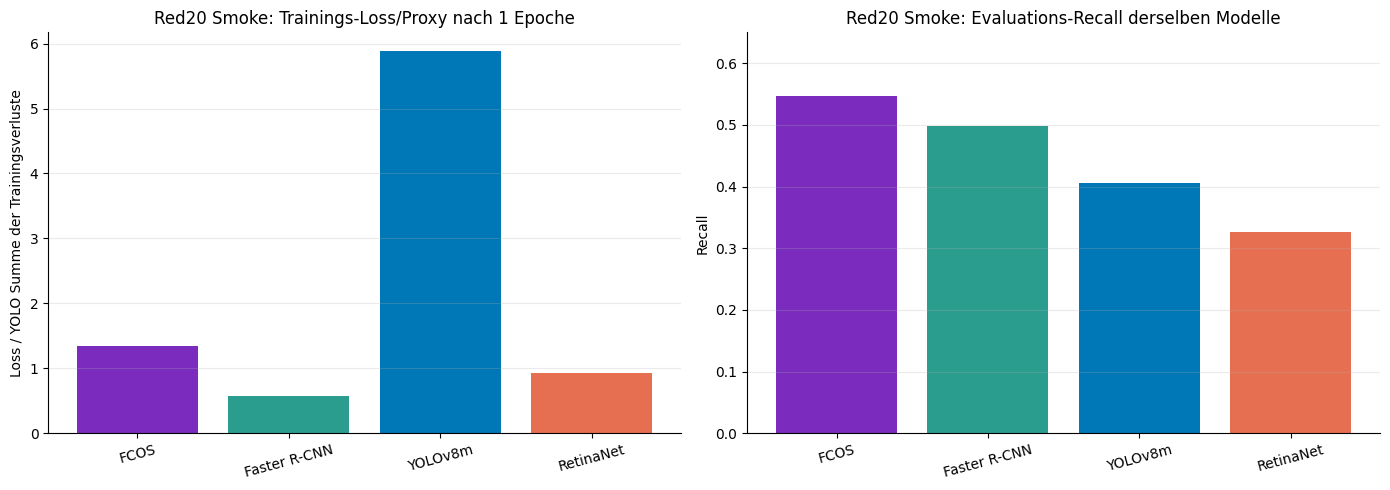

Gespeichert: /home/clemi/projekte/MIM/model_results/plots/step06_evaluation_lab_red20_training_vs_eval_latest.png


In [3]:
def read_csv(path):
    with path.open(newline='') as f:
        data = list(csv.DictReader(f))
    for row in data:
        for k, v in list(row.items()):
            try:
                row[k] = float(v)
            except Exception:
                pass
    return data

broad_colors = {
    'YOLOv8m': '#0077B6',
    'Faster R-CNN': '#2A9D8F',
    'RetinaNet': '#E76F51',
    'FCOS': '#7B2CBF',
}

broad_training_rows = []
for path in sorted(RESULTS_DIR.glob('training_history_*red20_ep1_*.csv')):
    hist = read_csv(path)
    if not hist:
        continue
    row = hist[-1]
    model_name = str(row.get('model', path.stem))
    model_family = family(model_name)
    eval_match = next((r for r in broad_trained if r['family'] == model_family), None)
    broad_training_rows.append({
        'family': model_family,
        'model': model_name,
        'epoch': int(row.get('epoch', 1)),
        'mean_loss': float(row.get('mean_loss', 0)),
        'batch': int(row.get('batch', 0)),
        'reduction': int(row.get('reduction', 0)),
        'images': int(row.get('images', 0)),
        'recall': eval_match['recall'] if eval_match else None,
        'ms_per_image': eval_match['ms_per_image'] if eval_match else None,
    })

yolo_broad_results = YOLO_RUNS_DIR / 'yolo_yolov8m_widerface_rocm_bs2_red20_ep1' / 'results.csv'
if yolo_broad_results.exists():
    yolo_hist = [{k.strip(): v for k, v in r.items()} for r in read_csv(yolo_broad_results)]
    if yolo_hist:
        row = yolo_hist[-1]
        eval_match = next((r for r in broad_trained if r['family'] == 'YOLOv8m'), None)
        broad_training_rows.append({
            'family': 'YOLOv8m',
            'model': 'yolo_yolov8m_widerface_rocm',
            'epoch': int(row.get('epoch', 1)),
            'mean_loss': float(row.get('train/box_loss', 0)) + float(row.get('train/cls_loss', 0)) + float(row.get('train/dfl_loss', 0)),
            'batch': 2,
            'reduction': 20,
            'images': 644,
            'recall': eval_match['recall'] if eval_match else None,
            'ms_per_image': eval_match['ms_per_image'] if eval_match else None,
            'yolo_precision': float(row.get('metrics/precision(B)', 0)),
            'yolo_recall': float(row.get('metrics/recall(B)', 0)),
            'yolo_map50': float(row.get('metrics/mAP50(B)', 0)),
        })

order = {'FCOS': 0, 'Faster R-CNN': 1, 'YOLOv8m': 2, 'RetinaNet': 3}
broad_training_rows = sorted(broad_training_rows, key=lambda r: order.get(r['family'], 99))
lines = [
    '| Modell | Epoche | Trainingsbilder | Batch | Reduction | Trainings-Loss/Proxy | Eval-Recall | ms/Bild | Zusatz |',
    '|---|---:|---:|---:|---:|---:|---:|---:|---|',
]
for r in broad_training_rows:
    extra = ''
    if r['family'] == 'YOLOv8m':
        extra = f"YOLO val Precision {r.get('yolo_precision', 0):.3f}, mAP50 {r.get('yolo_map50', 0):.3f}"
    lines.append(
        f"|{r['family']}|{r['epoch']}|{r['images']}|{r['batch']}|{r['reduction']}|{r['mean_loss']:.3f}|"
        f"{r['recall']:.3f}|{r['ms_per_image']:.1f}|{extra}|"
    )
display(Markdown('\n'.join(lines)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = [r['family'] for r in broad_training_rows]
axes[0].bar(labels, [r['mean_loss'] for r in broad_training_rows], color=[broad_colors.get(r['family'], '#555') for r in broad_training_rows])
axes[0].set_title('Red20 Smoke: Trainings-Loss/Proxy nach 1 Epoche')
axes[0].set_ylabel('Loss / YOLO Summe der Trainingsverluste')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(labels, [r['recall'] for r in broad_training_rows], color=[broad_colors.get(r['family'], '#555') for r in broad_training_rows])
axes[1].set_title('Red20 Smoke: Evaluations-Recall derselben Modelle')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 0.65)
axes[1].tick_params(axis='x', rotation=15)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
out = PLOTS_DIR / 'step06_evaluation_lab_red20_training_vs_eval_latest.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Gespeichert:', out)


## 3. Warum Faster R-CNN Und RetinaNet Nicht Weitergefuehrt Wurden

Faster R-CNN ist im Smoke-Vergleich staerker als YOLO beim Recall, verliert aber gegen FCOS und ist zugleich langsamer. RetinaNet ist schnell, findet aber deutlich weniger Gesichter. Fuer den vertieften Lauf wurden deshalb zwei unterschiedliche Staerken weiterverfolgt: FCOS als Recall-Sieger und YOLO als Pipeline-Sieger.

In [4]:
non_favorites = [r for r in broad_sorted if r['family'] in {'Faster R-CNN', 'RetinaNet'}]
lines = [
    '| Modell | Recall | ms/Bild | Warum kein Favorit? |',
    '|---|---:|---:|---|',
]
for row in non_favorites:
    lines.append(f"|{row['display_name']}|{row['recall']:.3f}|{row['ms_per_image']:.1f}|{row['reason']}|")
display(Markdown('\n'.join(lines)))


| Modell | Recall | ms/Bild | Warum kein Favorit? |
|---|---:|---:|---|
|fasterrcnn red20_ep1.pth|0.498|51.4|Nicht Favorit: guter Recall, aber langsamer und schwerfaelliger fuer Video.|
|retinanet red20_ep1.pth|0.327|35.0|Nicht Favorit: schnell, aber niedrigster Recall der trainierten Modelle.|

## 4. COCO-Baselines Als Kontrollgruppe

Die COCO-Baselines wurden nicht auf WIDER FACE trainiert. Sie zeigen nur, wie schlecht allgemeine Objektmodelle auf Face-Bounding-Boxes passen. Ihr schwaches Abschneiden begruendet das Face-Finetuning.

In [5]:
broad_baselines = sorted([r for r in broad_rows if r['is_baseline']], key=lambda r: r['recall'], reverse=True)
display(Markdown(markdown_table(broad_baselines)))


|Rang|Modell|Familie|Bilder|GT-Faces|Treffer|Recall|ms/Bild|
|---:|---|---|---:|---:|---:|---:|---:|
|1|COCO FCOS|COCO-Baseline|300|3443|122|0.035|36.5|
|2|COCO FASTERRCNN|COCO-Baseline|300|3443|86|0.025|51.0|
|3|COCO RETINANET|COCO-Baseline|300|3443|53|0.015|38.0|
|4|COCO YOLOV8M|COCO-Baseline|300|3443|29|0.008|14.6|

## 5. Uebergang Zu Den Zwei Favoriten

Die Entscheidung ist bewusst keine reine Top-2-nach-Recall-Auswahl. FCOS gewinnt als Qualitaetsmodell, YOLO gewinnt als Praxismodell fuer die Videopipeline. Deshalb werden genau diese beiden Kandidaten in einem laengeren Red6/10-Epochen-Lauf auf gleicher Datenbasis erneut verglichen.

## 6. Favoritenvergleich Auf Ca. 2.000 Trainingsbildern

YOLOv8m und FCOS wurden mit Reduction 6, Batch Size 2 und 10 Epochen trainiert. Die Evaluation nutzt 500 Validierungsbilder mit 5.015 Ground-Truth-Faces.

In [6]:
deep_sorted = sorted(deep_rows, key=lambda r: r['recall'], reverse=True)
for row in deep_sorted:
    if row['family'] == 'FCOS' and not row['is_baseline']:
        row['reason'] = 'Recall-Sieger nach laengerem Training.'
    elif row['family'] == 'YOLOv8m' and not row['is_baseline']:
        row['reason'] = 'Schneller und direkter fuer Video-Pipeline.'
    elif row['is_baseline']:
        row['reason'] = 'Kontrollbaseline, nicht face-finetuned.'
    else:
        row['reason'] = ''
display(Markdown(markdown_table(deep_sorted, include_reason=True)))


|Rang|Modell|Familie|Bilder|GT-Faces|Treffer|Recall|ms/Bild|Bewertung|
|---:|---|---|---:|---:|---:|---:|---:|---|
|1|fcos red6_ep10.pth|FCOS|500|5015|3375|0.673|55.7|Recall-Sieger nach laengerem Training.|
|2|yolo_yolov8m red6_ep10.pt|YOLOv8m|500|5015|2445|0.488|31.2|Schneller und direkter fuer Video-Pipeline.|
|3|COCO FCOS|COCO-Baseline|500|5015|224|0.045|44.6|Kontrollbaseline, nicht face-finetuned.|
|4|COCO YOLOV8M|COCO-Baseline|500|5015|46|0.009|17.3|Kontrollbaseline, nicht face-finetuned.|

## 7. Implementierte Metriken

Die Haupttabellen vergleichen alle Modelle mit den Metriken, die fuer alle Detektoren einheitlich vorliegen. Precision und F1 werden im Threshold-Sweep fuer Torchvision-Modelle berechnet; YOLO liefert zusaetzlich Precision/Recall/mAP im eigenen `results.csv`.

In [7]:
metric_lines = [
    '| Metrik | Bedeutung | Rolle im Projekt |',
    '|---|---|---|',
    '| Recall | Anteil gefundener Ground-Truth-Gesichter | wichtigste Datenschutzmetrik |',
    '| Treffer | absolut gematchte Face-Boxes | macht Recall greifbar |',
    '| ms/Bild | Inferenzzeit pro Bild | Praxisrelevant fuer Video |',
    '| Precision | Anteil korrekter Vorhersagen an allen Vorhersagen | wichtig gegen unnoetige Blur-Boxen |',
    '| F1 | harmonisches Mittel aus Precision und Recall | hilft bei Threshold-Wahl |',
    '| mAP50 / mAP50-95 | Ultralytics-Qualitaetsmetriken | YOLO-Detailbewertung, nicht direkt die Skript-Hauptmetrik |',
]
display(Markdown('\n'.join(metric_lines)))

sweeps = deep_meta.get('threshold_sweeps', [])
if sweeps:
    lines = ['| Modell | Threshold | Precision | Recall | F1 | Treffer | Vorhersagen |', '|---|---:|---:|---:|---:|---:|---:|']
    for s in sweeps:
        precision = float(s.get('precision', 0))
        recall = float(s.get('recall', 0))
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0
        lines.append(f"|{Path(str(s['model'])).name}|{float(s['score_threshold']):.2f}|{precision:.3f}|{recall:.3f}|{f1:.3f}|{int(s.get('detected_faces', 0))}|{int(s.get('predicted_faces', 0))}|")
    display(Markdown('### Threshold-Sweep Favoritenlauf\n' + '\n'.join(lines)))


| Metrik | Bedeutung | Rolle im Projekt |
|---|---|---|
| Recall | Anteil gefundener Ground-Truth-Gesichter | wichtigste Datenschutzmetrik |
| Treffer | absolut gematchte Face-Boxes | macht Recall greifbar |
| ms/Bild | Inferenzzeit pro Bild | Praxisrelevant fuer Video |
| Precision | Anteil korrekter Vorhersagen an allen Vorhersagen | wichtig gegen unnoetige Blur-Boxen |
| F1 | harmonisches Mittel aus Precision und Recall | hilft bei Threshold-Wahl |
| mAP50 / mAP50-95 | Ultralytics-Qualitaetsmetriken | YOLO-Detailbewertung, nicht direkt die Skript-Hauptmetrik |

### Threshold-Sweep Favoritenlauf
| Modell | Threshold | Precision | Recall | F1 | Treffer | Vorhersagen |
|---|---:|---:|---:|---:|---:|---:|
|fcos_resnet50_fpn_rocm_bs2_red6_ep10.pth|0.25|0.612|0.673|0.641|3375|5514|
|fcos_resnet50_fpn_rocm_bs2_red6_ep10.pth|0.50|0.891|0.571|0.696|2865|3217|
|fcos_resnet50_fpn_rocm_bs2_red6_ep10.pth|0.70|0.966|0.465|0.627|2330|2412|

## 8. Vergleichsgrafiken

Die folgenden Grafiken zeigen Recall, Latenz, COCO-Vergleich und Threshold-Sweep. Die `latest`-Grafiken werden aus dem Favoritenlauf erzeugt.

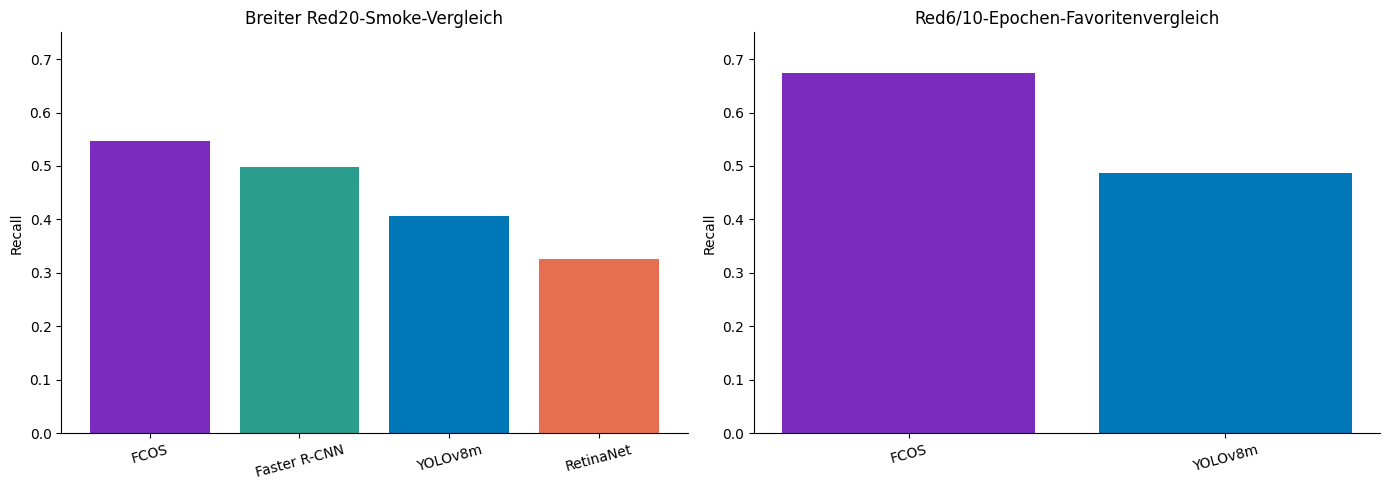

Gespeichert: /home/clemi/projekte/MIM/model_results/plots/step06_evaluation_lab_zweistufiger_modellvergleich_latest.png


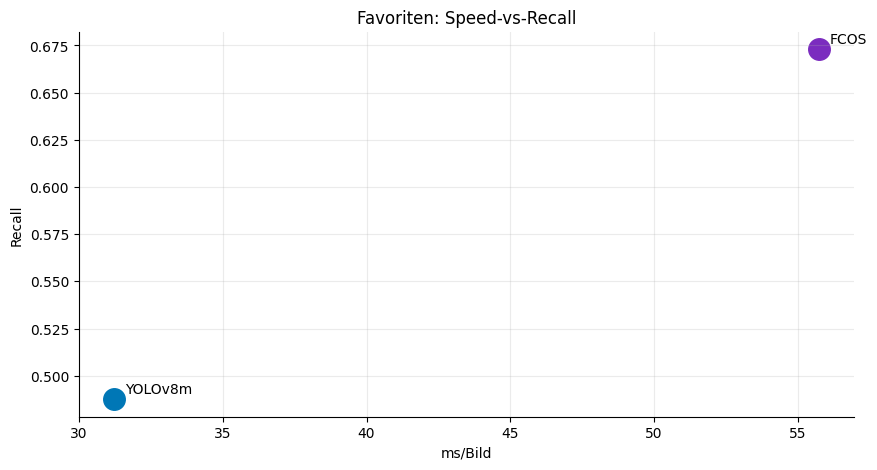

Gespeichert: /home/clemi/projekte/MIM/model_results/plots/step06_evaluation_lab_favoriten_speed_vs_recall_latest.png


In [8]:
colors = {
    'YOLOv8m': '#0077B6',
    'Faster R-CNN': '#2A9D8F',
    'RetinaNet': '#E76F51',
    'FCOS': '#7B2CBF',
    'COCO-Baseline': '#8D99AE',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, title, rows in [
    (axes[0], 'Breiter Red20-Smoke-Vergleich', broad_sorted),
    (axes[1], 'Red6/10-Epochen-Favoritenvergleich', [r for r in deep_sorted if not r['is_baseline']]),
]:
    names = [r['family'] for r in rows]
    ax.bar(names, [r['recall'] for r in rows], color=[colors.get(r['family'], '#555') for r in rows])
    ax.set_title(title)
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 0.75)
    ax.tick_params(axis='x', rotation=15)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
out = PLOTS_DIR / 'step06_evaluation_lab_zweistufiger_modellvergleich_latest.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Gespeichert:', out)

fig, ax = plt.subplots(figsize=(10, 5))
for row in [r for r in deep_sorted if not r['is_baseline']]:
    ax.scatter(row['ms_per_image'], row['recall'], s=240, color=colors.get(row['family']), label=row['family'])
    ax.annotate(row['family'], (row['ms_per_image'], row['recall']), xytext=(8, 4), textcoords='offset points')
ax.set_title('Favoriten: Speed-vs-Recall')
ax.set_xlabel('ms/Bild')
ax.set_ylabel('Recall')
ax.grid(True, alpha=0.25)
ax.spines[['top','right']].set_visible(False)
out = PLOTS_DIR / 'step06_evaluation_lab_favoriten_speed_vs_recall_latest.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Gespeichert:', out)


## 8.5 Praesentations-Dashboard

Aus `Notebook_gesamt.ipynb` ist vor allem die kompakte Vergleichsgrafik sinnvoll: mehrere Modellkennzahlen werden nebeneinander dargestellt, sodass die Entscheidung fuer FCOS und YOLO in einer Folie erklaerbar ist. Feature-Visualisierungen wie HOG/LBP/Canny sind fuer diese Face-Detection-Evaluation weniger relevant, weil hier trainierte Detektoren und keine klassischen Bildfeatures bewertet werden.

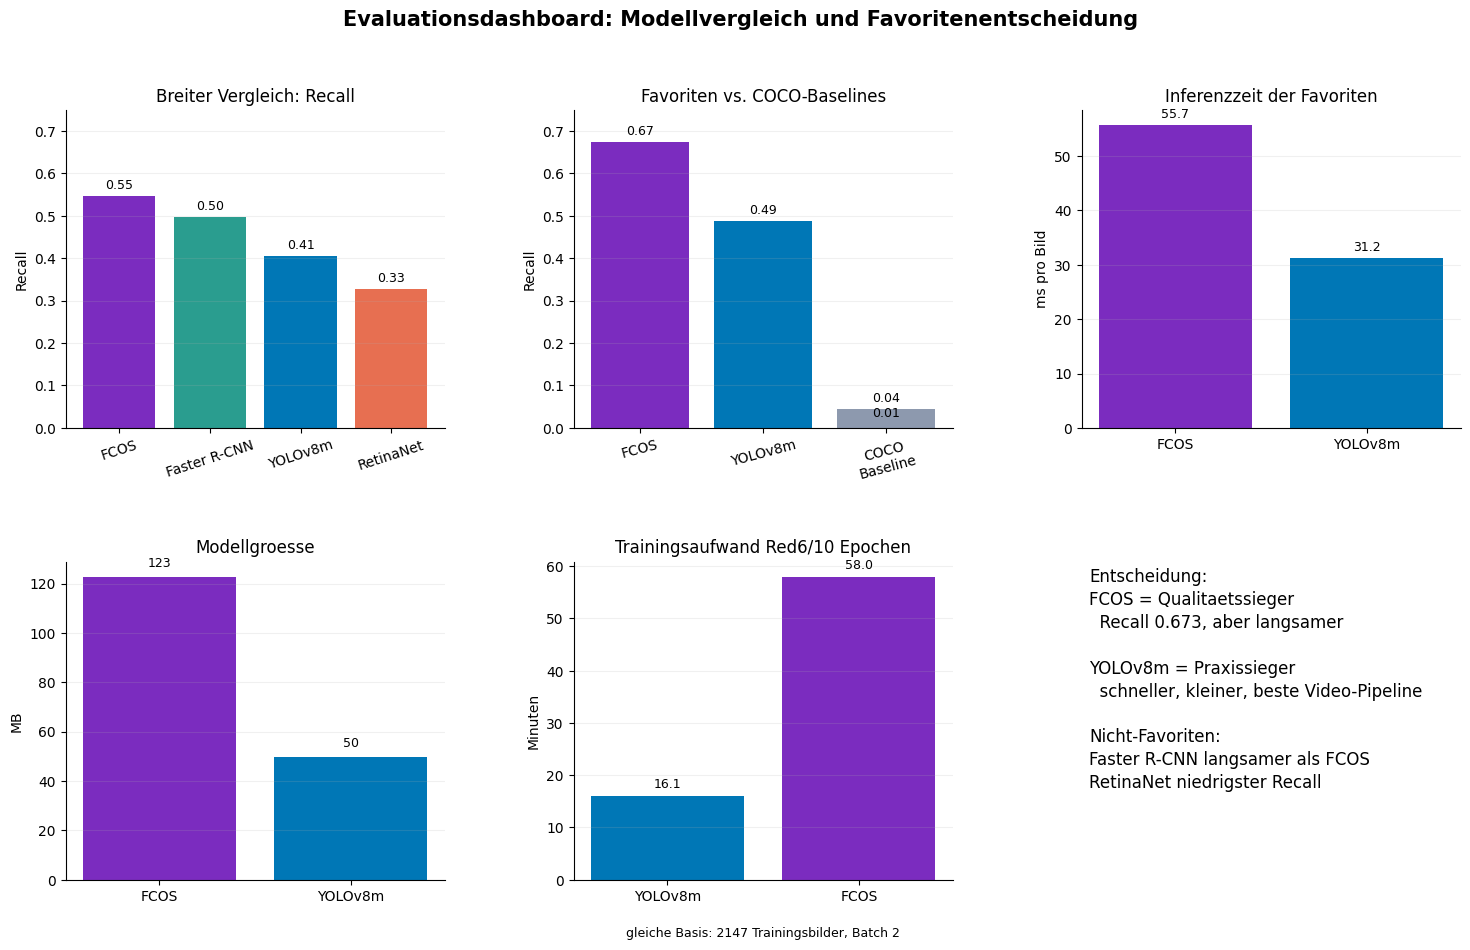

Gespeichert: /home/clemi/projekte/MIM/model_results/plots/step06_evaluation_lab_praesentationsdashboard_latest.png


In [9]:
from matplotlib.gridspec import GridSpec


def model_file_for(row):
    name = row['model']
    if name.startswith('BASELINE'):
        return None
    return ROOT / 'trained_models' / name


def size_mb_for(row):
    path = model_file_for(row)
    return path.stat().st_size / (1024 * 1024) if path and path.exists() else 0


def value_labels(ax, bars, fmt='{:.2f}', dy=0.01):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + dy, fmt.format(h), ha='center', va='bottom', fontsize=9)

fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.34)
fig.suptitle('Evaluationsdashboard: Modellvergleich und Favoritenentscheidung', fontsize=15, fontweight='bold')

# 1: Breiter Red20-Recall
ax = fig.add_subplot(gs[0, 0])
rows = broad_sorted
bars = ax.bar([r['family'] for r in rows], [r['recall'] for r in rows], color=[colors.get(r['family'], '#666') for r in rows])
ax.set_title('Breiter Vergleich: Recall')
ax.set_ylabel('Recall')
ax.set_ylim(0, 0.75)
ax.tick_params(axis='x', rotation=18)
value_labels(ax, bars)

# 2: Favoriten + COCO-Baselines
ax = fig.add_subplot(gs[0, 1])
rows = deep_sorted
names = [r['family'] if not r['is_baseline'] else r['family'].replace('COCO-', 'COCO\n') for r in rows]
bars = ax.bar(names, [r['recall'] for r in rows], color=[colors.get(r['family'], '#8D99AE') for r in rows])
ax.set_title('Favoriten vs. COCO-Baselines')
ax.set_ylabel('Recall')
ax.set_ylim(0, 0.75)
ax.tick_params(axis='x', rotation=15)
value_labels(ax, bars)

# 3: Geschwindigkeit im Favoritenlauf
ax = fig.add_subplot(gs[0, 2])
rows = [r for r in deep_sorted if not r['is_baseline']]
bars = ax.bar([r['family'] for r in rows], [r['ms_per_image'] for r in rows], color=[colors.get(r['family'], '#666') for r in rows])
ax.set_title('Inferenzzeit der Favoriten')
ax.set_ylabel('ms pro Bild')
value_labels(ax, bars, fmt='{:.1f}', dy=0.8)

# 4: Modellgroesse
ax = fig.add_subplot(gs[1, 0])
rows = [r for r in deep_sorted if not r['is_baseline']]
bars = ax.bar([r['family'] for r in rows], [size_mb_for(r) for r in rows], color=[colors.get(r['family'], '#666') for r in rows])
ax.set_title('Modellgroesse')
ax.set_ylabel('MB')
value_labels(ax, bars, fmt='{:.0f}', dy=3)

# 5: Training und Datenbasis
ax = fig.add_subplot(gs[1, 1])
train_names = ['YOLOv8m', 'FCOS']
train_minutes = [16.1, 58.0]
bars = ax.bar(train_names, train_minutes, color=[colors['YOLOv8m'], colors['FCOS']])
ax.set_title('Trainingsaufwand Red6/10 Epochen')
ax.set_ylabel('Minuten')
value_labels(ax, bars, fmt='{:.1f}', dy=1)
ax.text(0.5, -0.18, 'gleiche Basis: 2147 Trainingsbilder, Batch 2', transform=ax.transAxes, ha='center', fontsize=9)

# 6: Entscheidungsprofil
ax = fig.add_subplot(gs[1, 2])
ax.axis('off')
decision_text = (
    'Entscheidung:\n'
    'FCOS = Qualitaetssieger\n'
    '  Recall 0.673, aber langsamer\n\n'
    'YOLOv8m = Praxissieger\n'
    '  schneller, kleiner, beste Video-Pipeline\n\n'
    'Nicht-Favoriten:\n'
    'Faster R-CNN langsamer als FCOS\n'
    'RetinaNet niedrigster Recall'
)
ax.text(0.02, 0.98, decision_text, va='top', fontsize=12, linespacing=1.35)

for ax in fig.axes:
    if ax.has_data():
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=0.18)

out = PLOTS_DIR / 'step06_evaluation_lab_praesentationsdashboard_latest.png'
plt.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Gespeichert:', out)


## 9. Vom Evaluationsskript Erzeugte Grafiken

### evaluation_20260623_124037

**dataset_train_vs_val_20260623_124037.png**

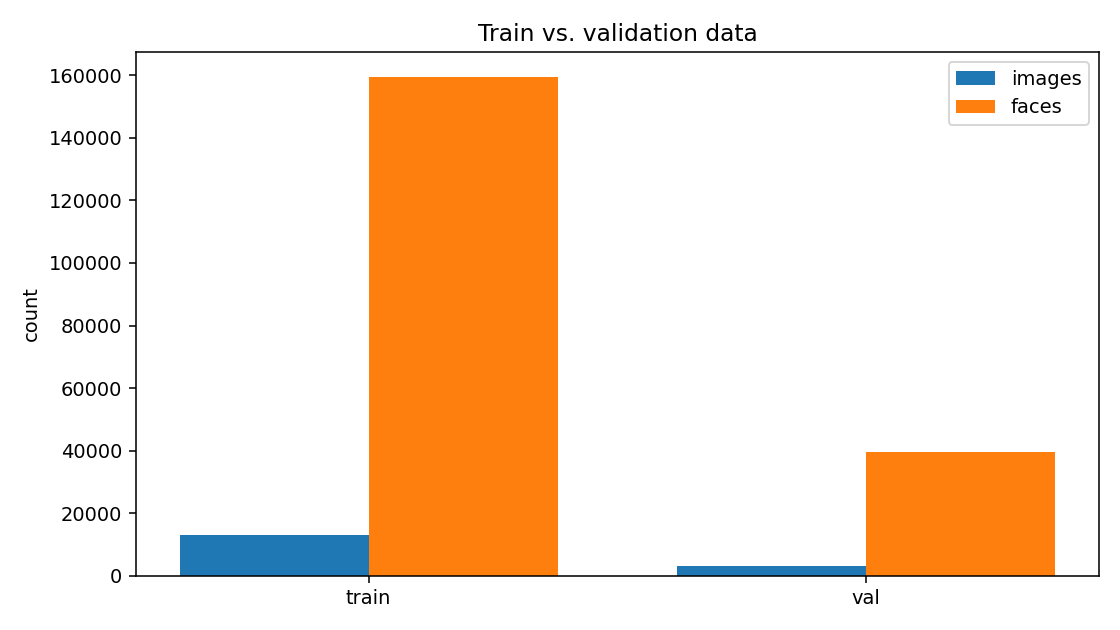

**validation_recall_20260623_124037.png**

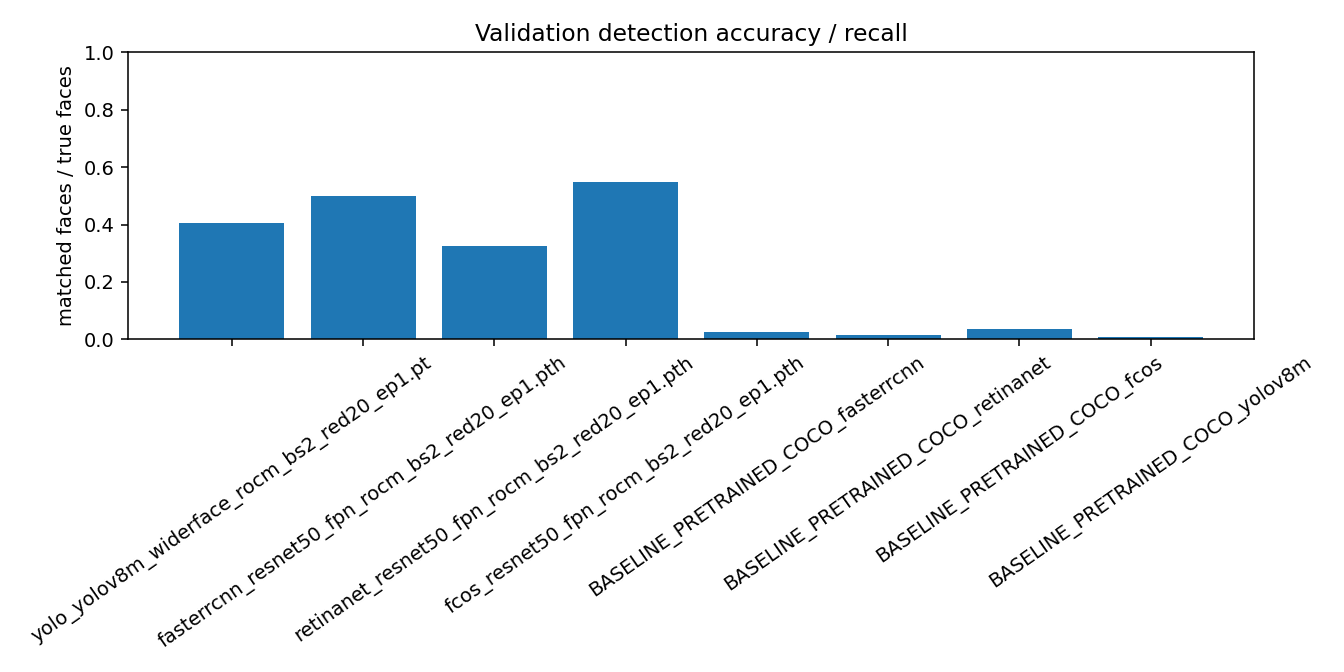

**validation_latency_20260623_124037.png**

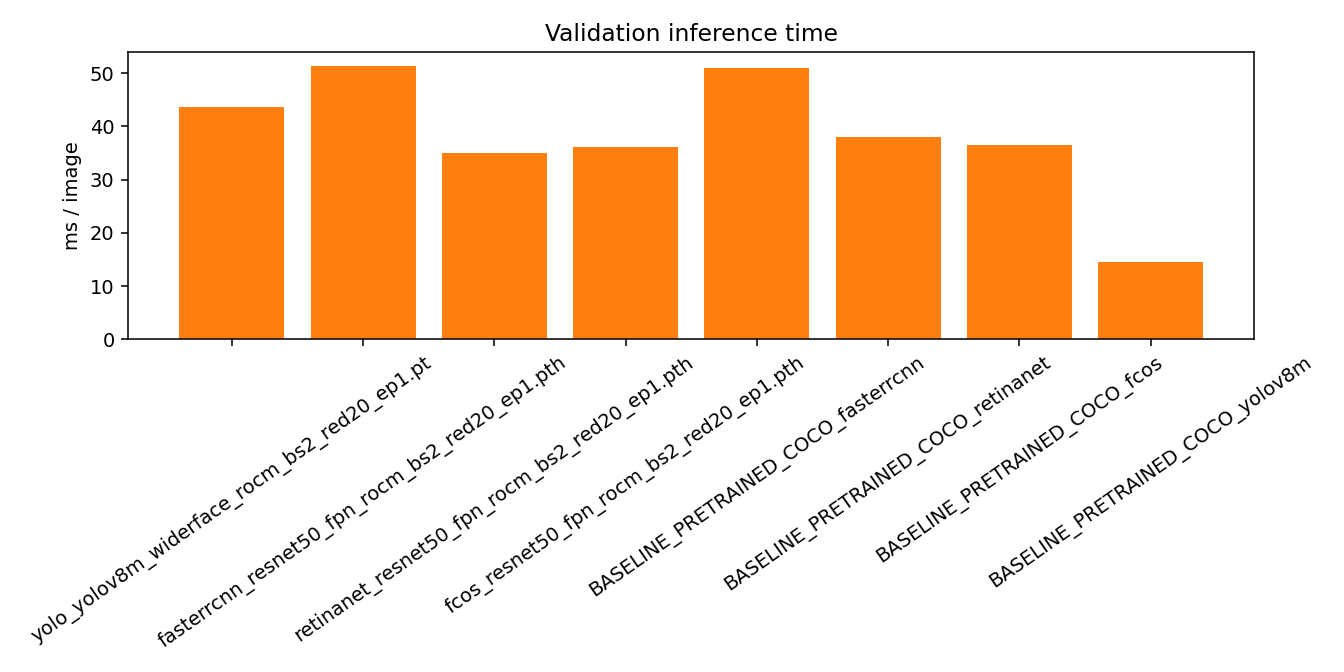

**threshold_sweep_20260623_124037.png**

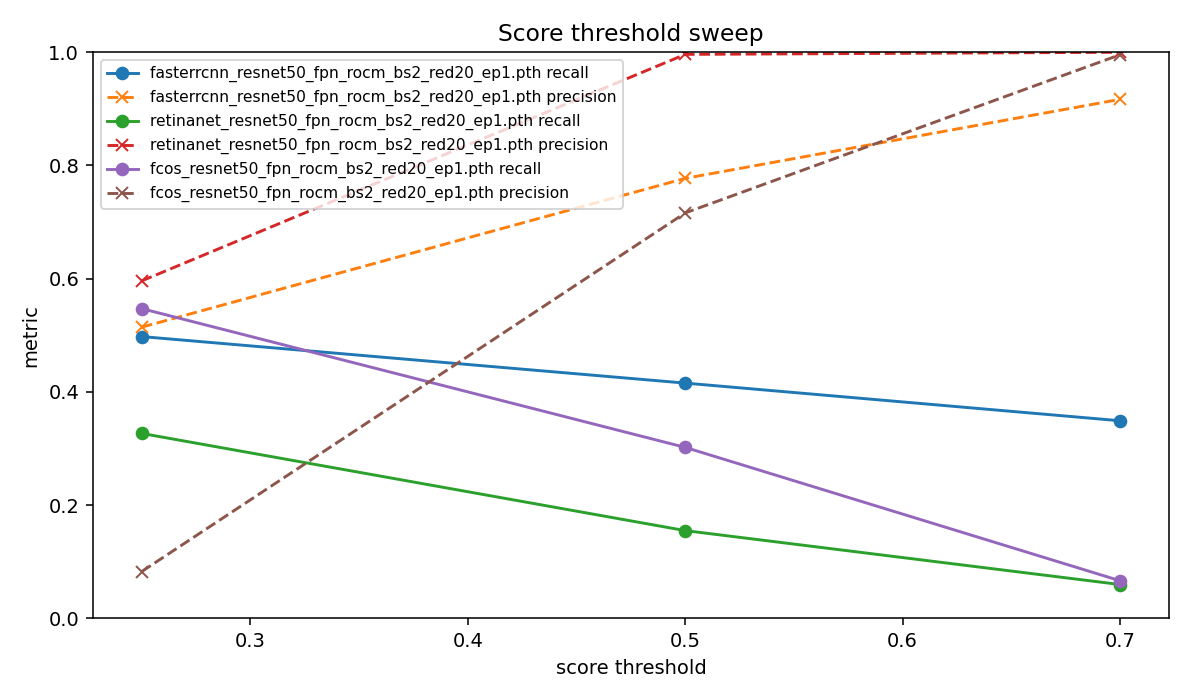

### evaluation_20260623_151450

**dataset_train_vs_val_20260623_151450.png**

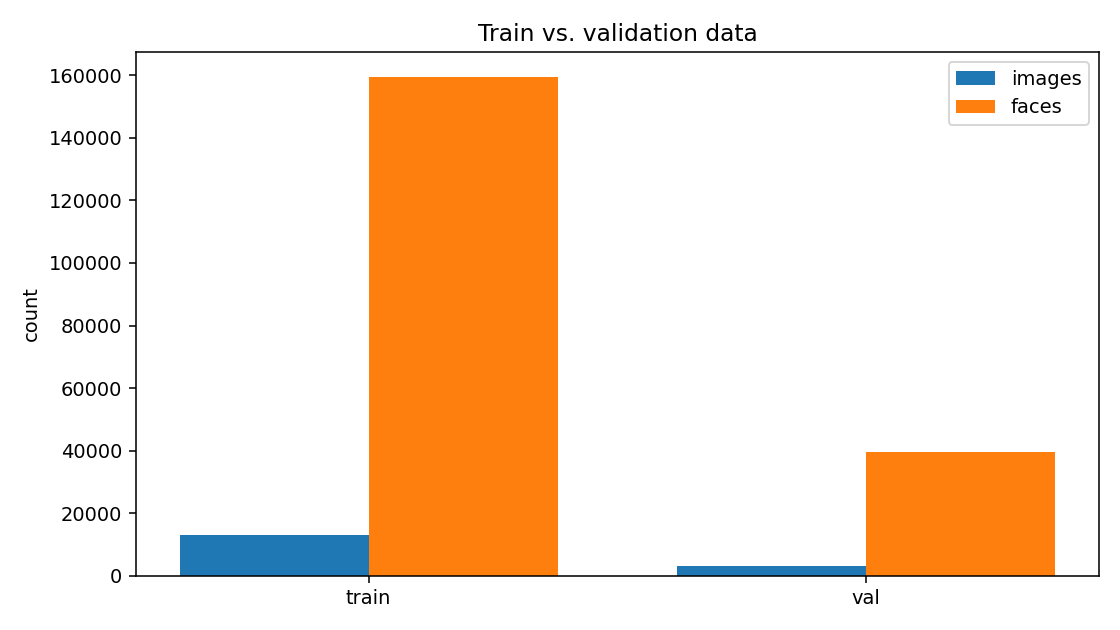

**validation_recall_20260623_151450.png**

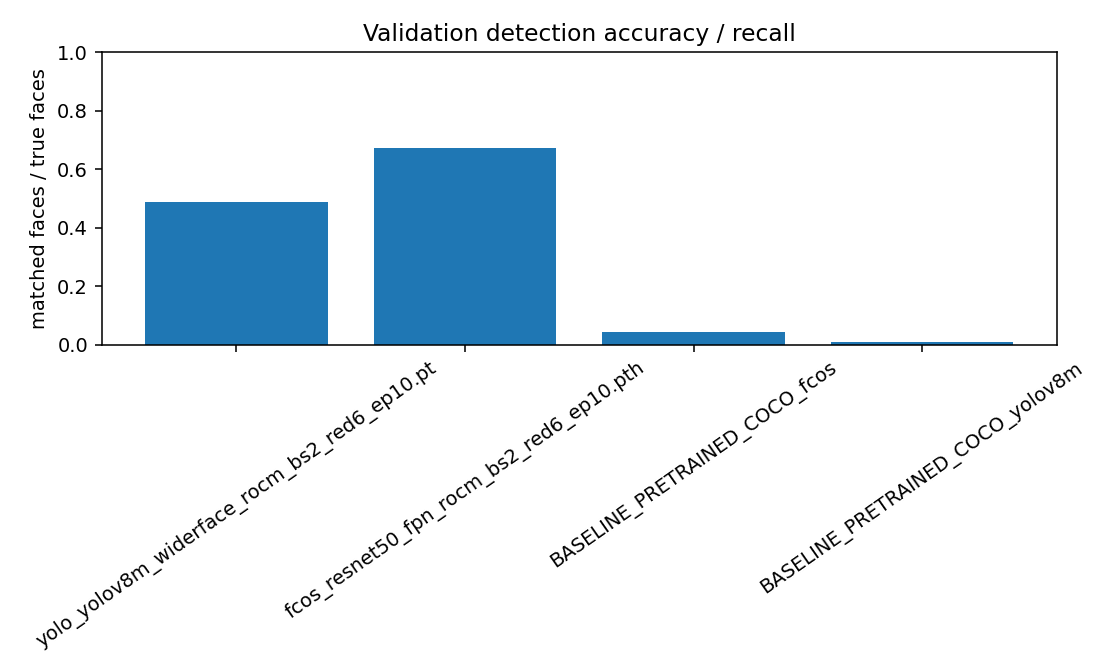

**validation_latency_20260623_151450.png**

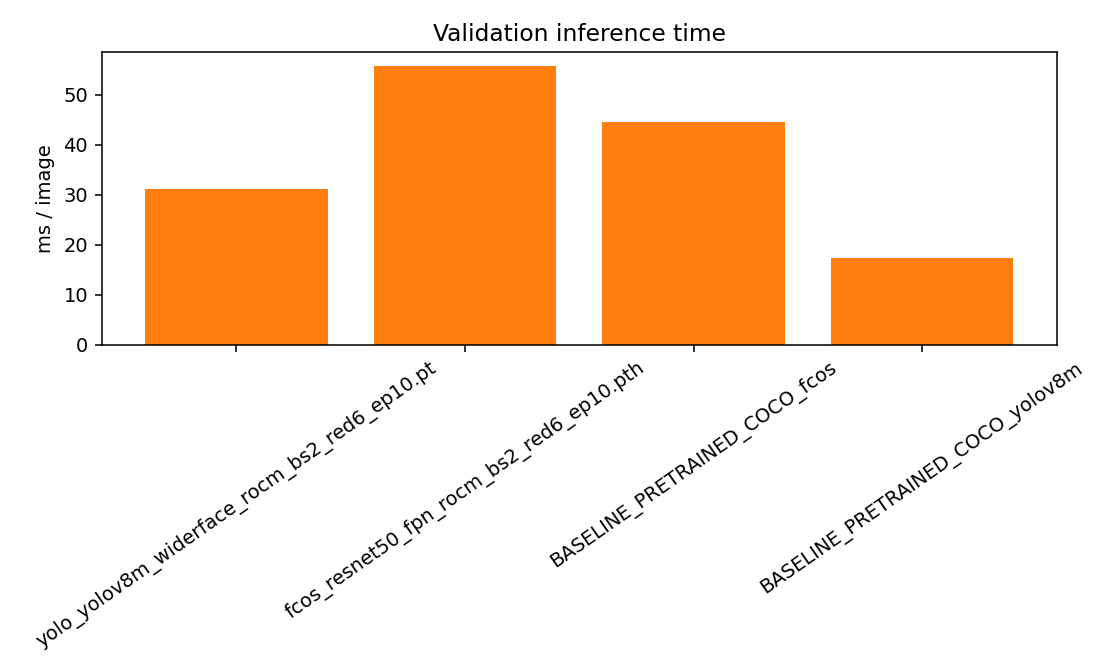

**threshold_sweep_20260623_151450.png**

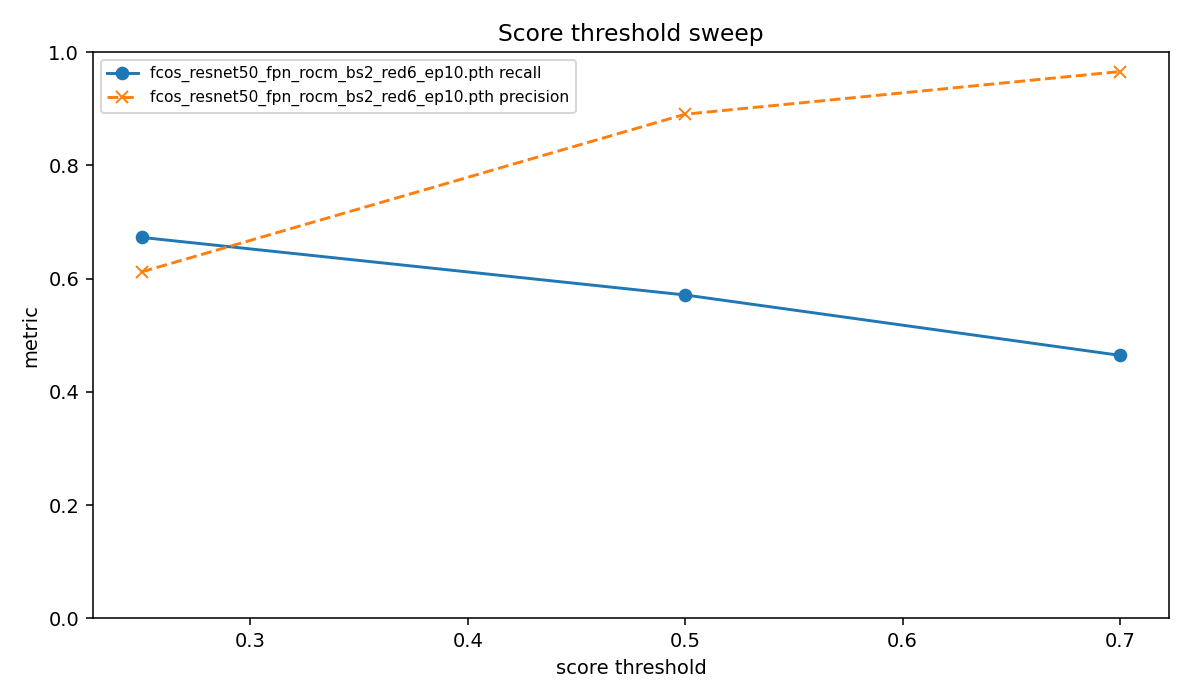

In [10]:
for stem in [BROAD_STEM, DEEP_STEM]:
    display(Markdown(f'### {stem}'))
    for name in [
        f'dataset_train_vs_val_{stem.replace("evaluation_", "")}.png',
        f'validation_recall_{stem.replace("evaluation_", "")}.png',
        f'validation_latency_{stem.replace("evaluation_", "")}.png',
        f'threshold_sweep_{stem.replace("evaluation_", "")}.png',
    ]:
        path = PLOTS_DIR / name
        if path.exists():
            display(Markdown(f'**{name}**'))
            display(Image(filename=str(path)))
        else:
            print('Fehlt:', path)


## 10. Lernkurven Und YOLO-Model-Results

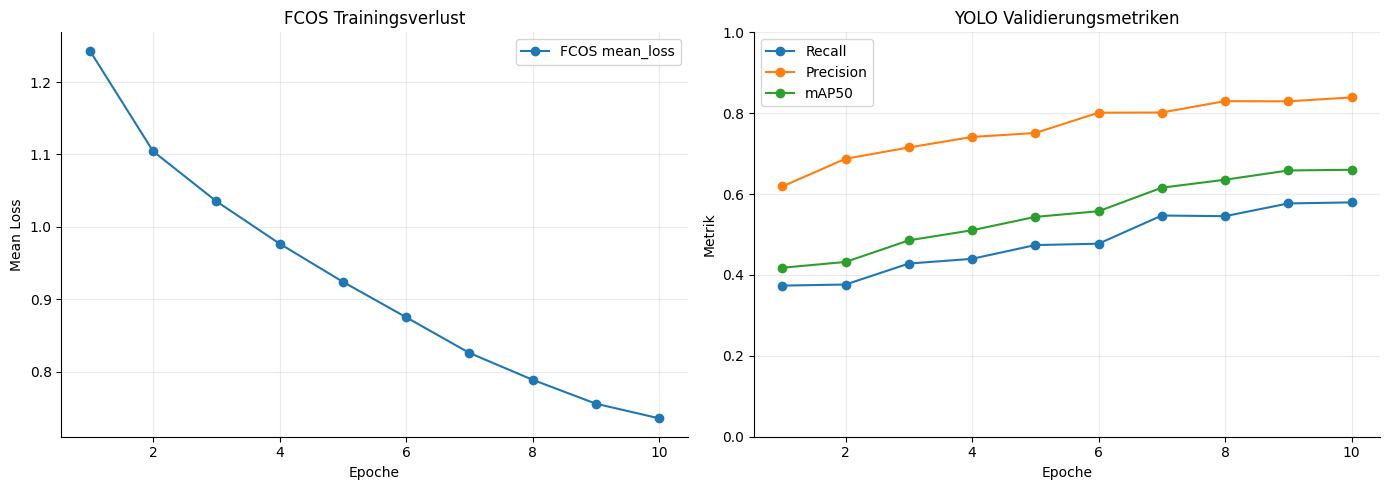

Gespeichert: /home/clemi/projekte/MIM/model_results/plots/step06_evaluation_lab_lernkurven_loss_accuracy_proxy_latest.png


In [11]:
def read_csv(path):
    with path.open(newline='') as f:
        data = list(csv.DictReader(f))
    for row in data:
        for k, v in list(row.items()):
            try:
                row[k] = float(v)
            except Exception:
                pass
    return data

fcos_history = sorted(RESULTS_DIR.glob('training_history_fcos_resnet50_fpn_rocm_bs2_red6_ep10_*.csv'))[-1]
yolo_run = YOLO_RUNS_DIR / 'yolo_yolov8m_widerface_rocm_bs2_red6_ep10'
yolo_results = yolo_run / 'results.csv'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
f_hist = read_csv(fcos_history)
axes[0].plot([r['epoch'] for r in f_hist], [r['mean_loss'] for r in f_hist], marker='o', label='FCOS mean_loss')
axes[0].set_title('FCOS Trainingsverlust')
axes[0].set_xlabel('Epoche')
axes[0].set_ylabel('Mean Loss')
axes[0].grid(True, alpha=0.25)
axes[0].legend()

if yolo_results.exists():
    y_hist = [{k.strip(): v for k, v in r.items()} for r in read_csv(yolo_results)]
    epochs = [r['epoch'] for r in y_hist]
    for col, label in [('metrics/recall(B)', 'Recall'), ('metrics/precision(B)', 'Precision'), ('metrics/mAP50(B)', 'mAP50')]:
        axes[1].plot(epochs, [r[col] for r in y_hist], marker='o', label=label)
axes[1].set_title('YOLO Validierungsmetriken')
axes[1].set_xlabel('Epoche')
axes[1].set_ylabel('Metrik')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.25)
axes[1].legend()
for ax in axes:
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
out = PLOTS_DIR / 'step06_evaluation_lab_lernkurven_loss_accuracy_proxy_latest.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Gespeichert:', out)


## 11. YOLO-Detailartefakte Fuer Die Video-Pipeline

YOLO Run: /home/clemi/projekte/MIM/trained_models/yolo_runs/yolo_yolov8m_widerface_rocm_bs2_red6_ep10


**results.png**

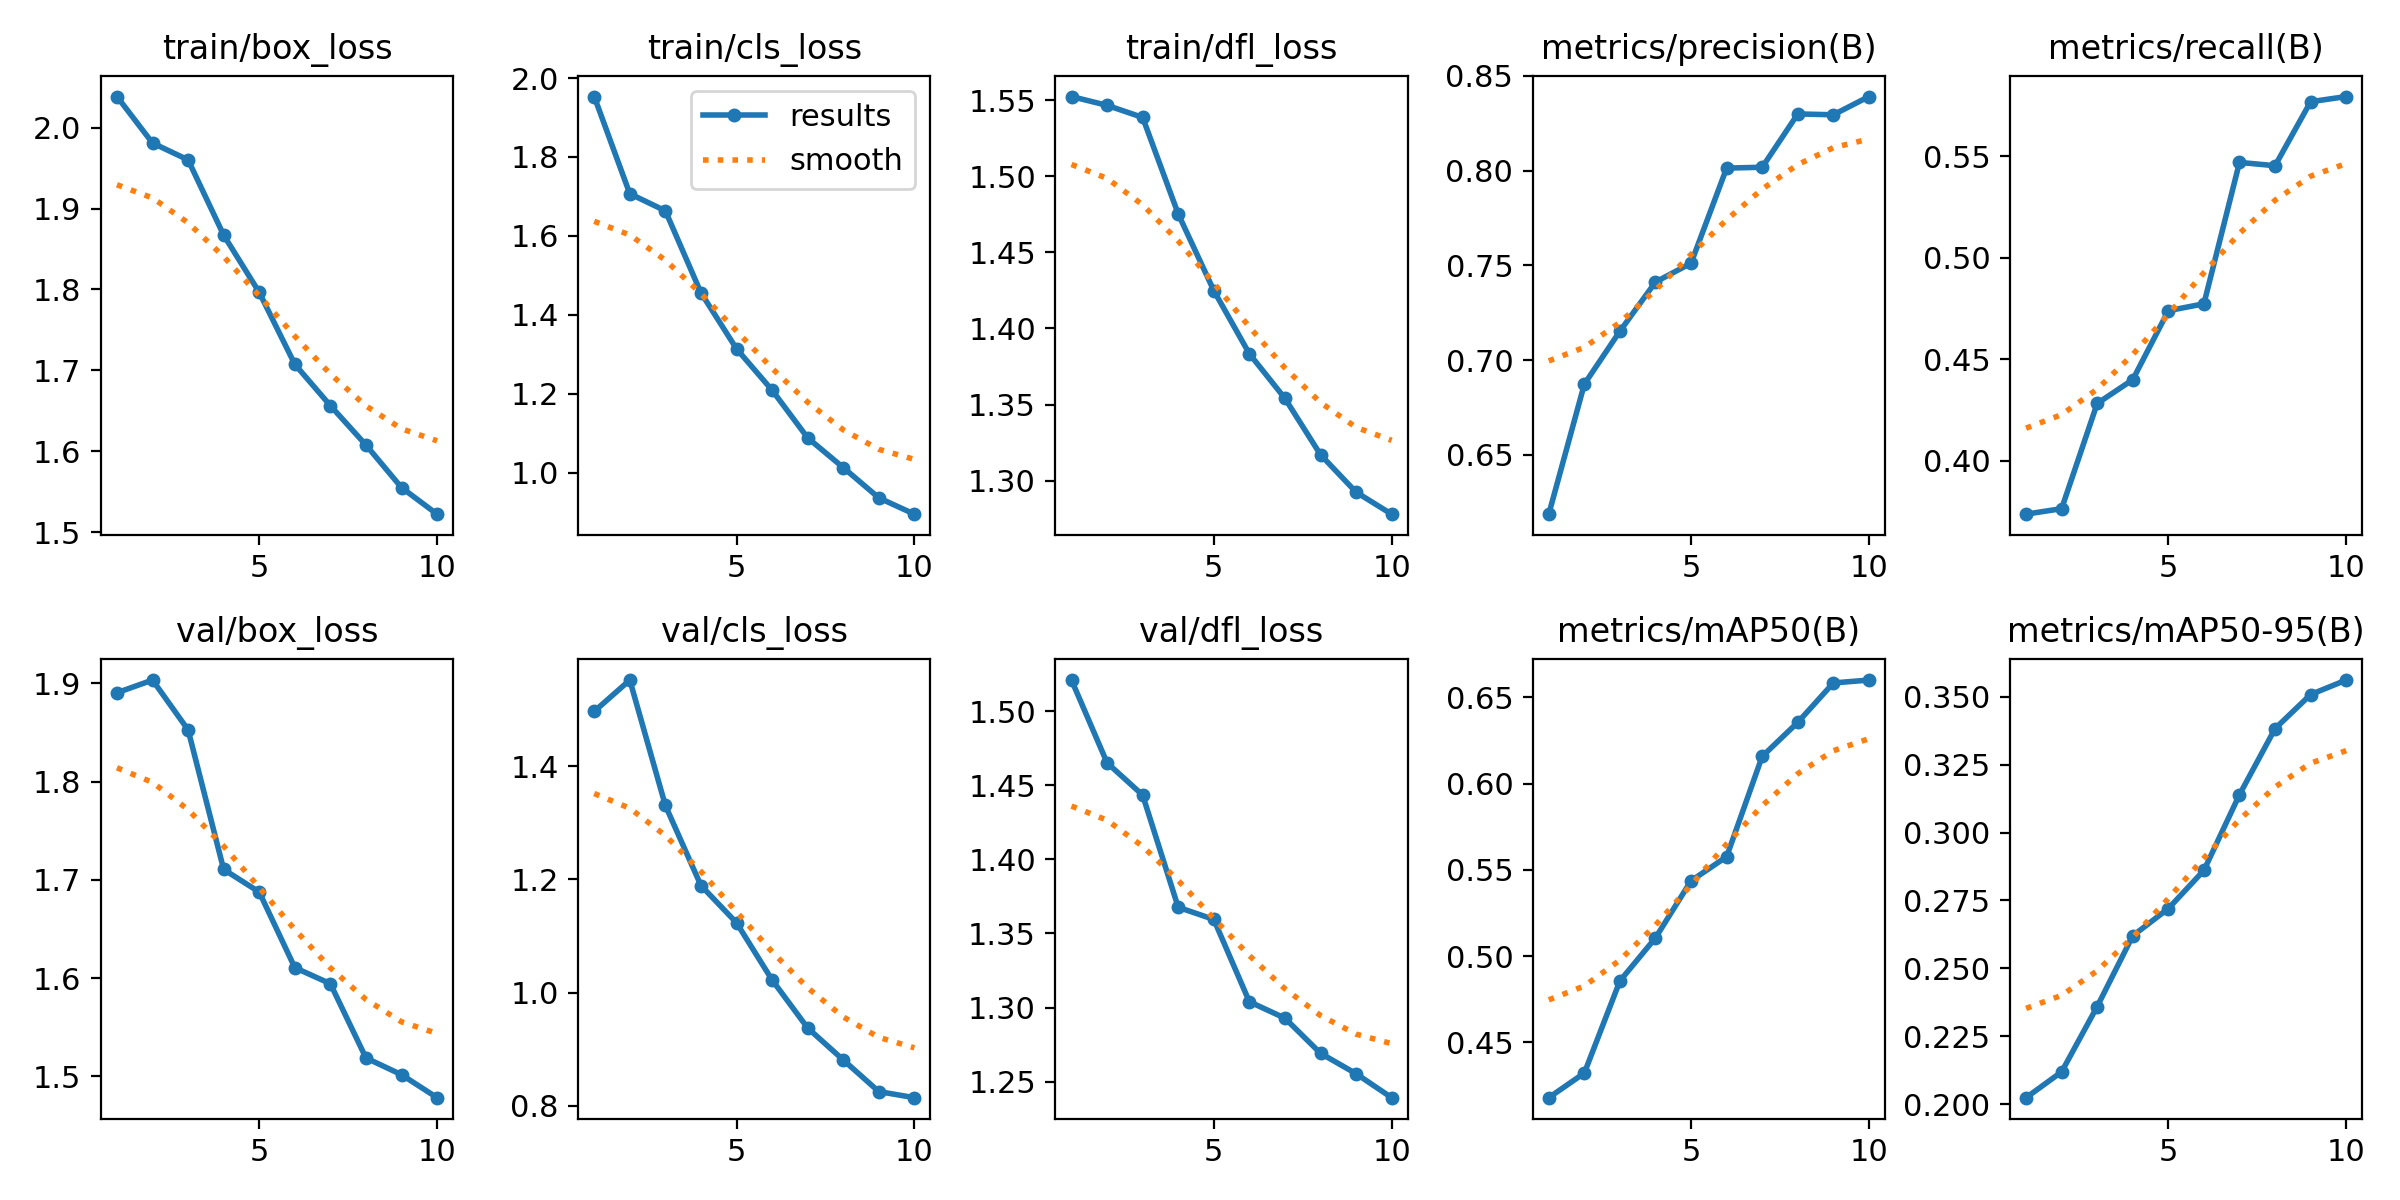

**confusion_matrix.png**

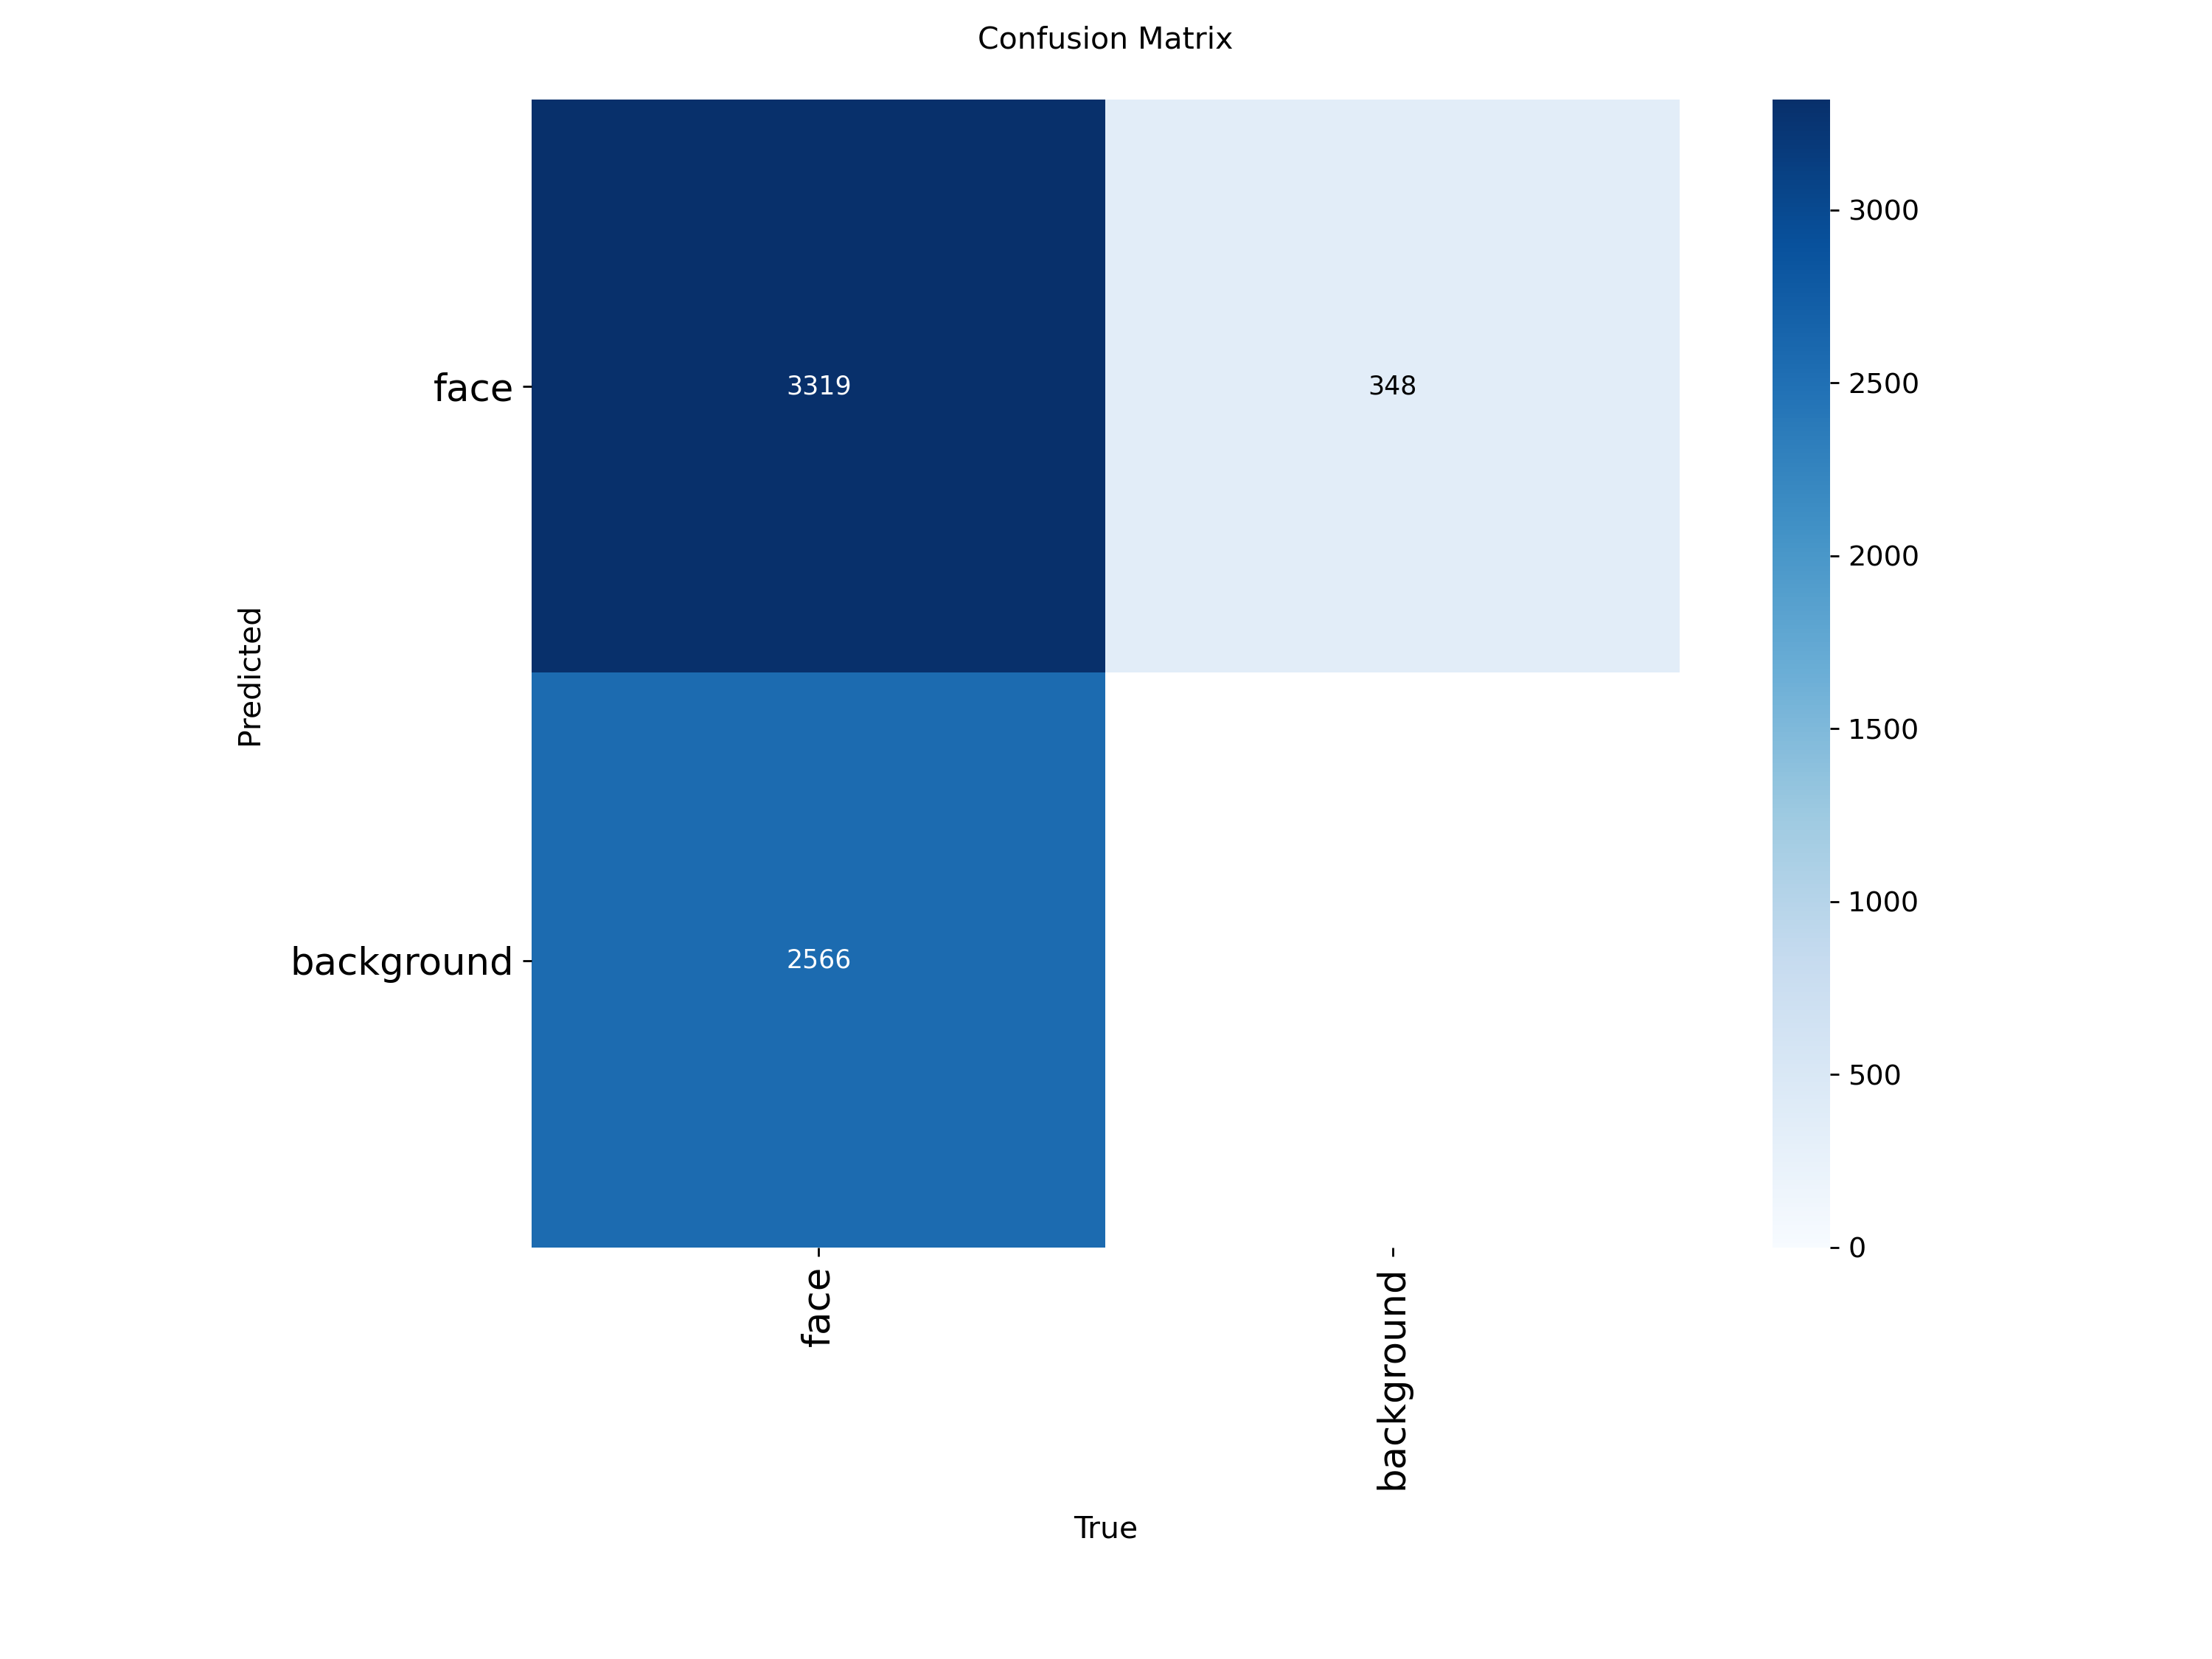

**confusion_matrix_normalized.png**

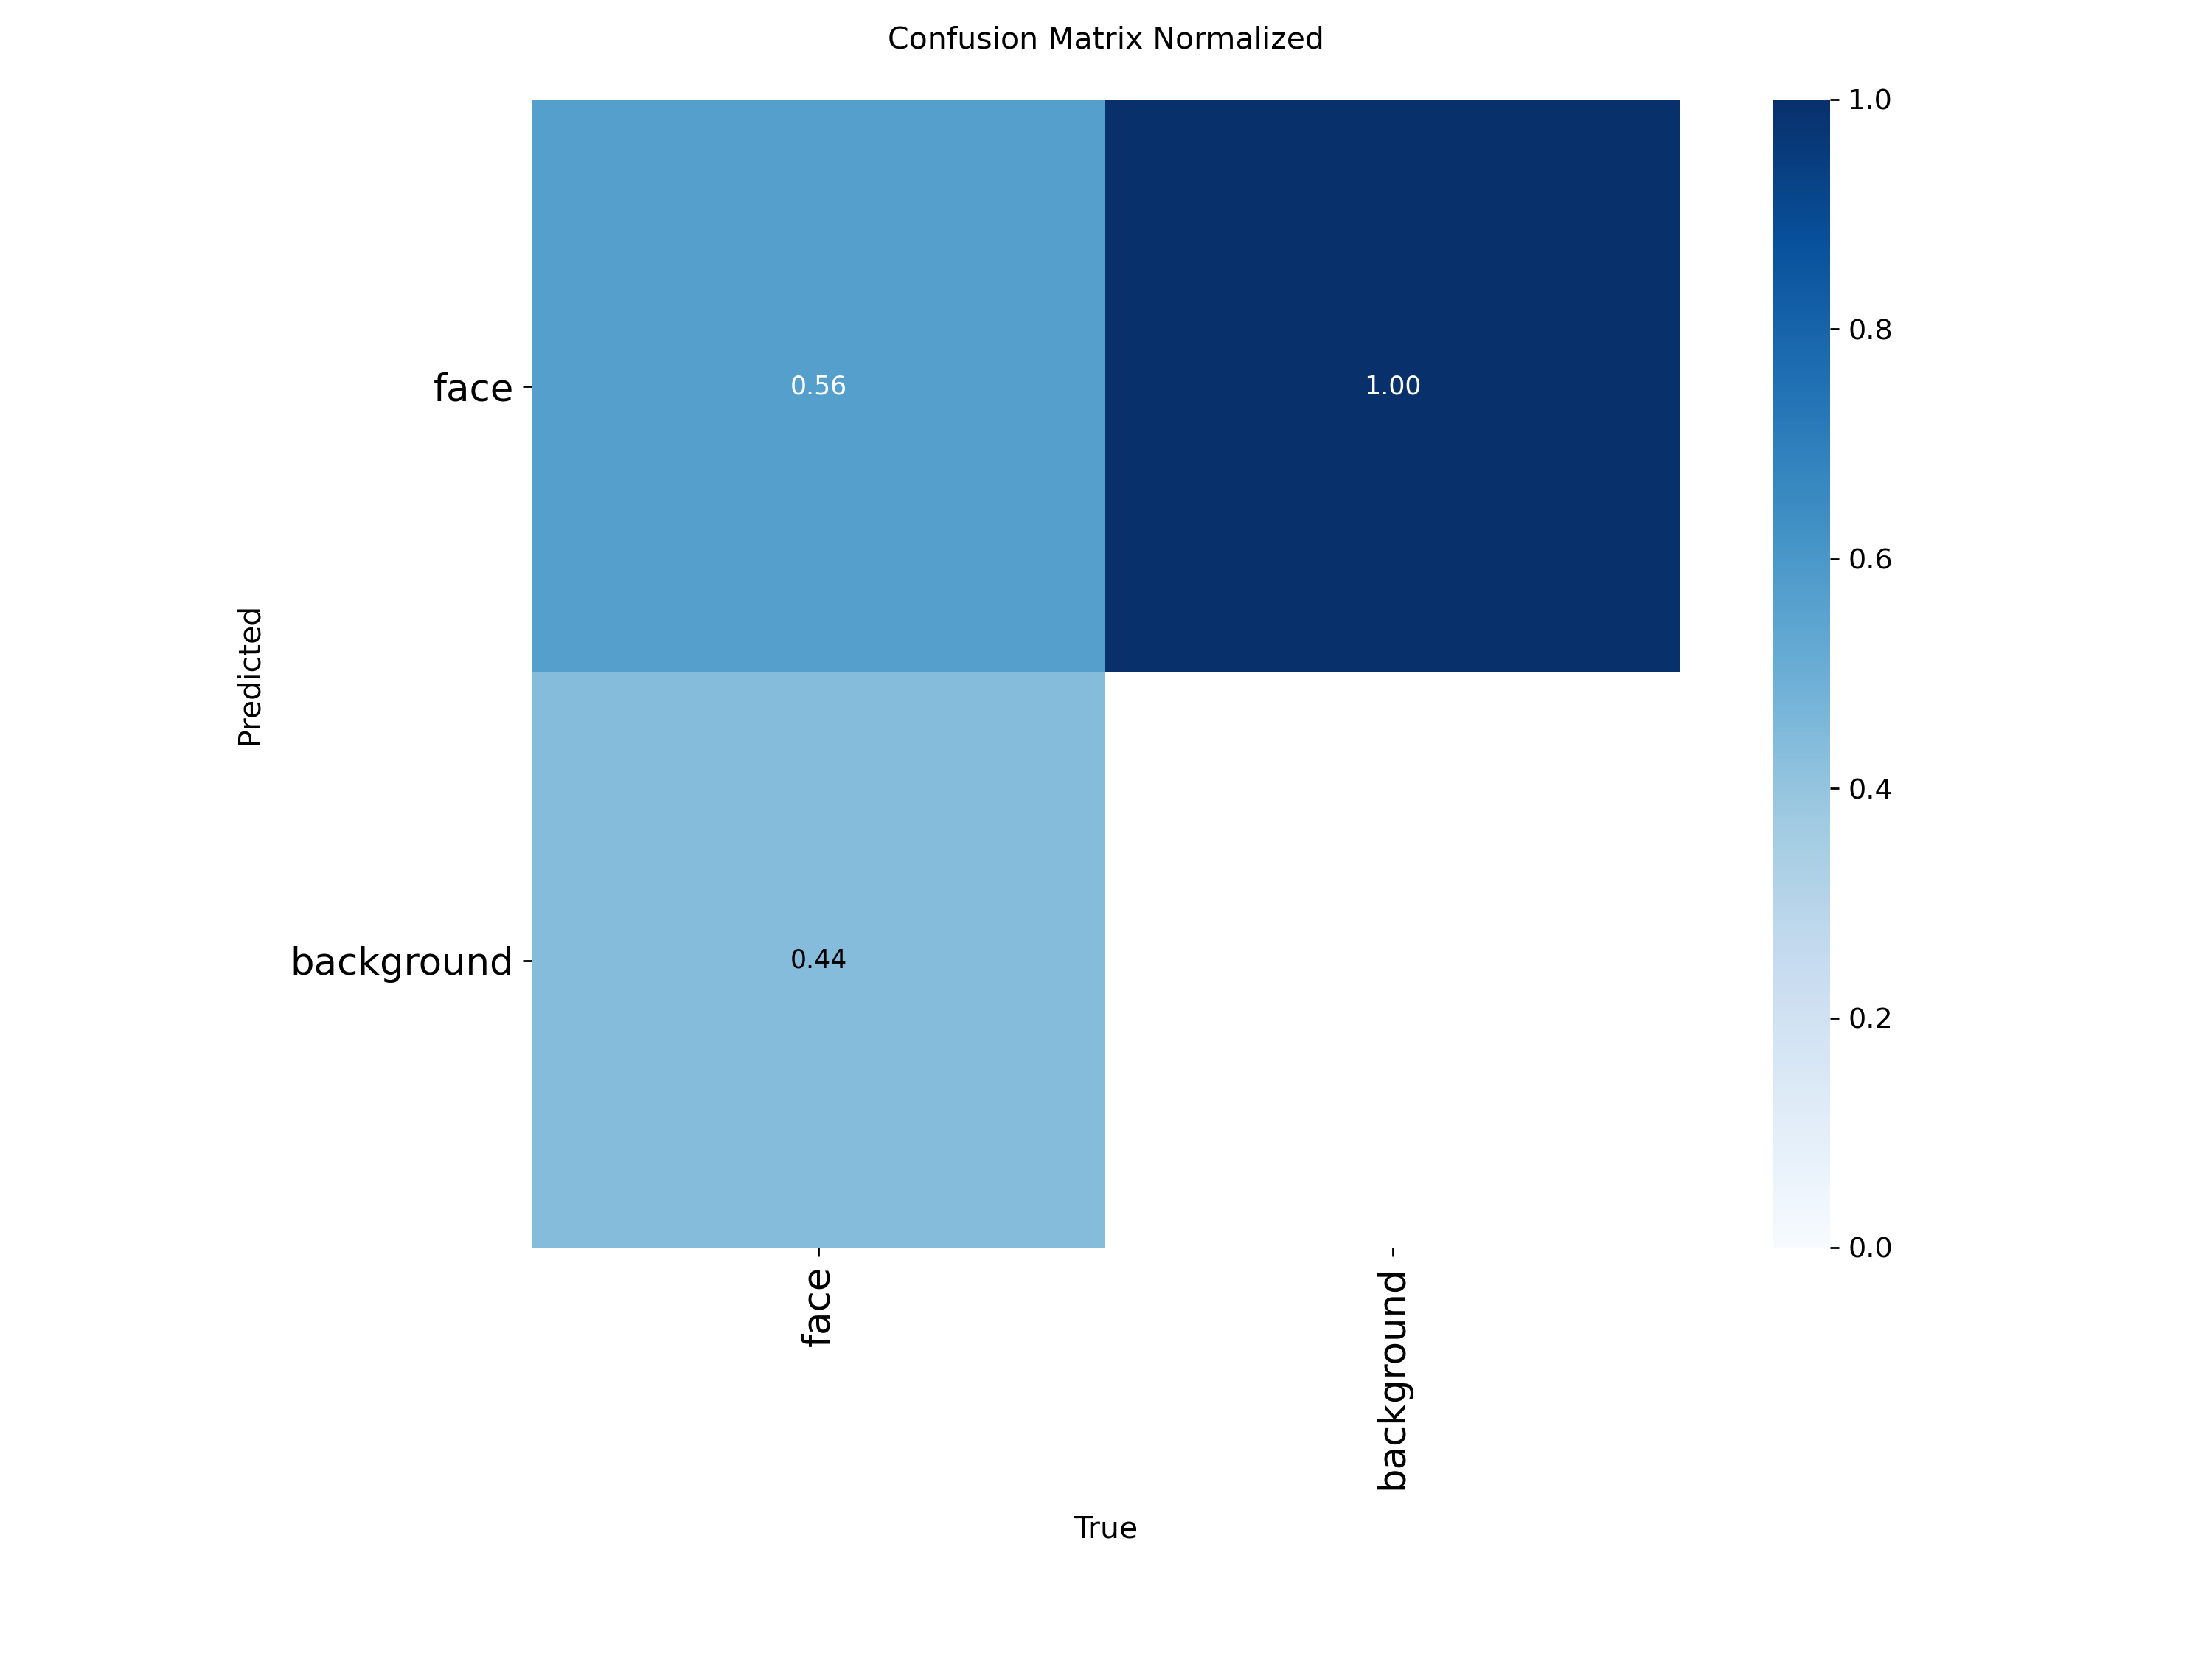

**BoxF1_curve.png**

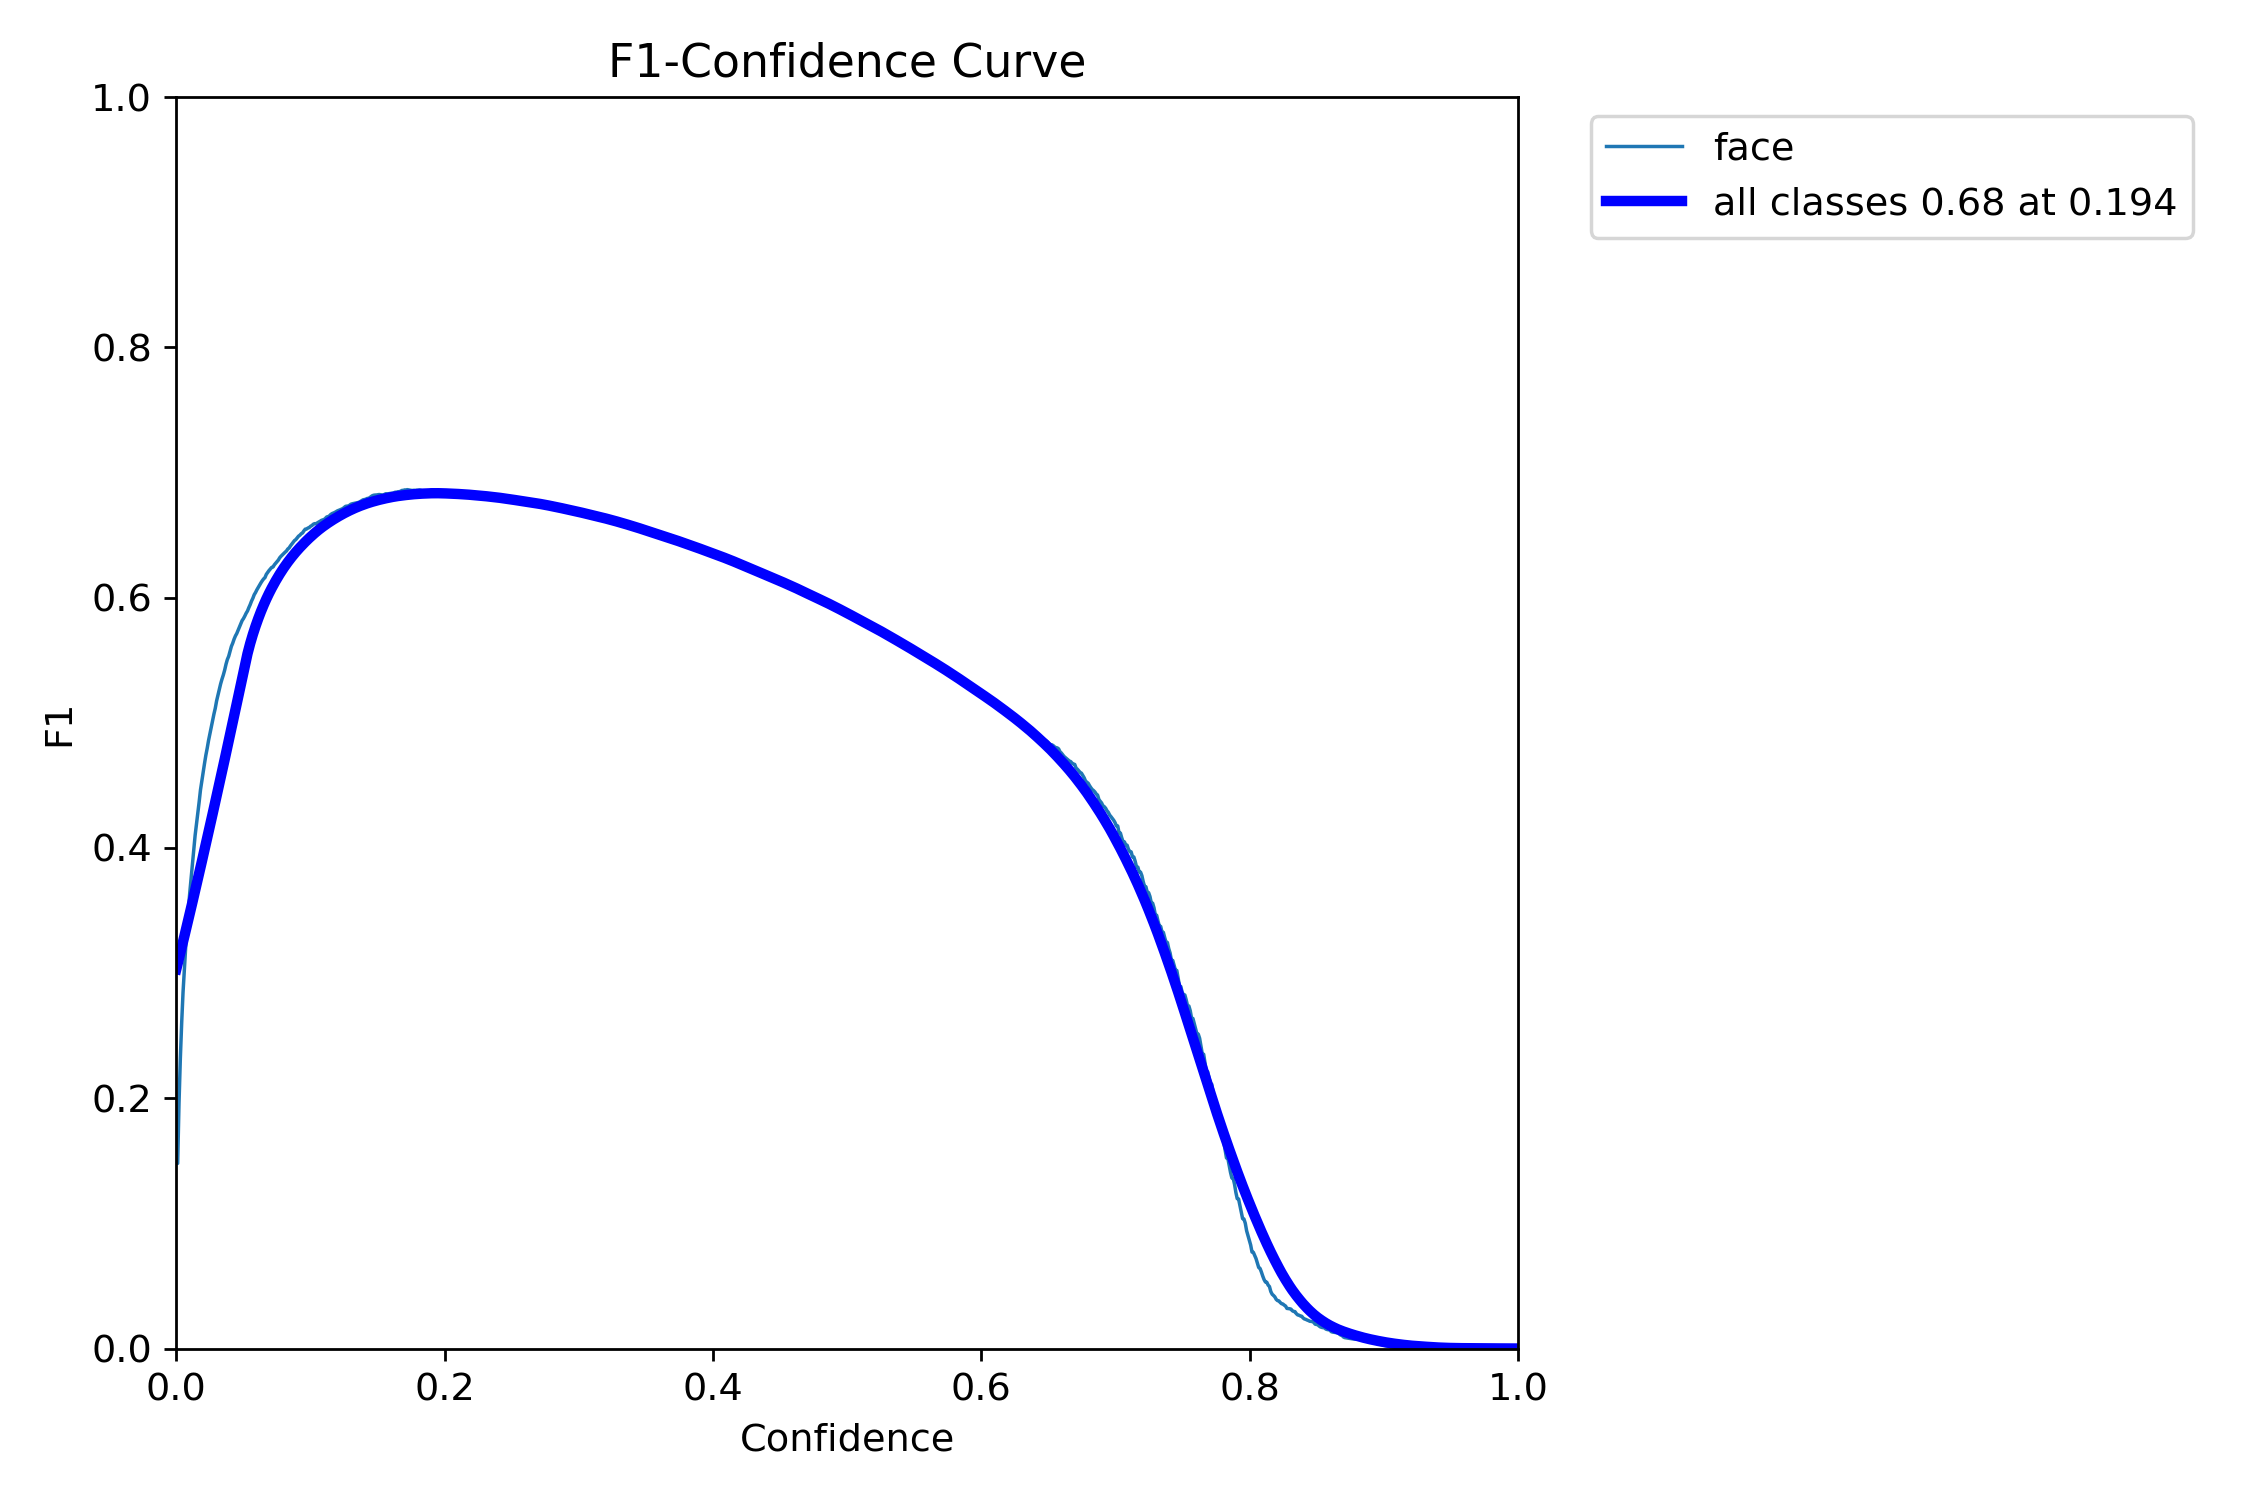

**BoxPR_curve.png**

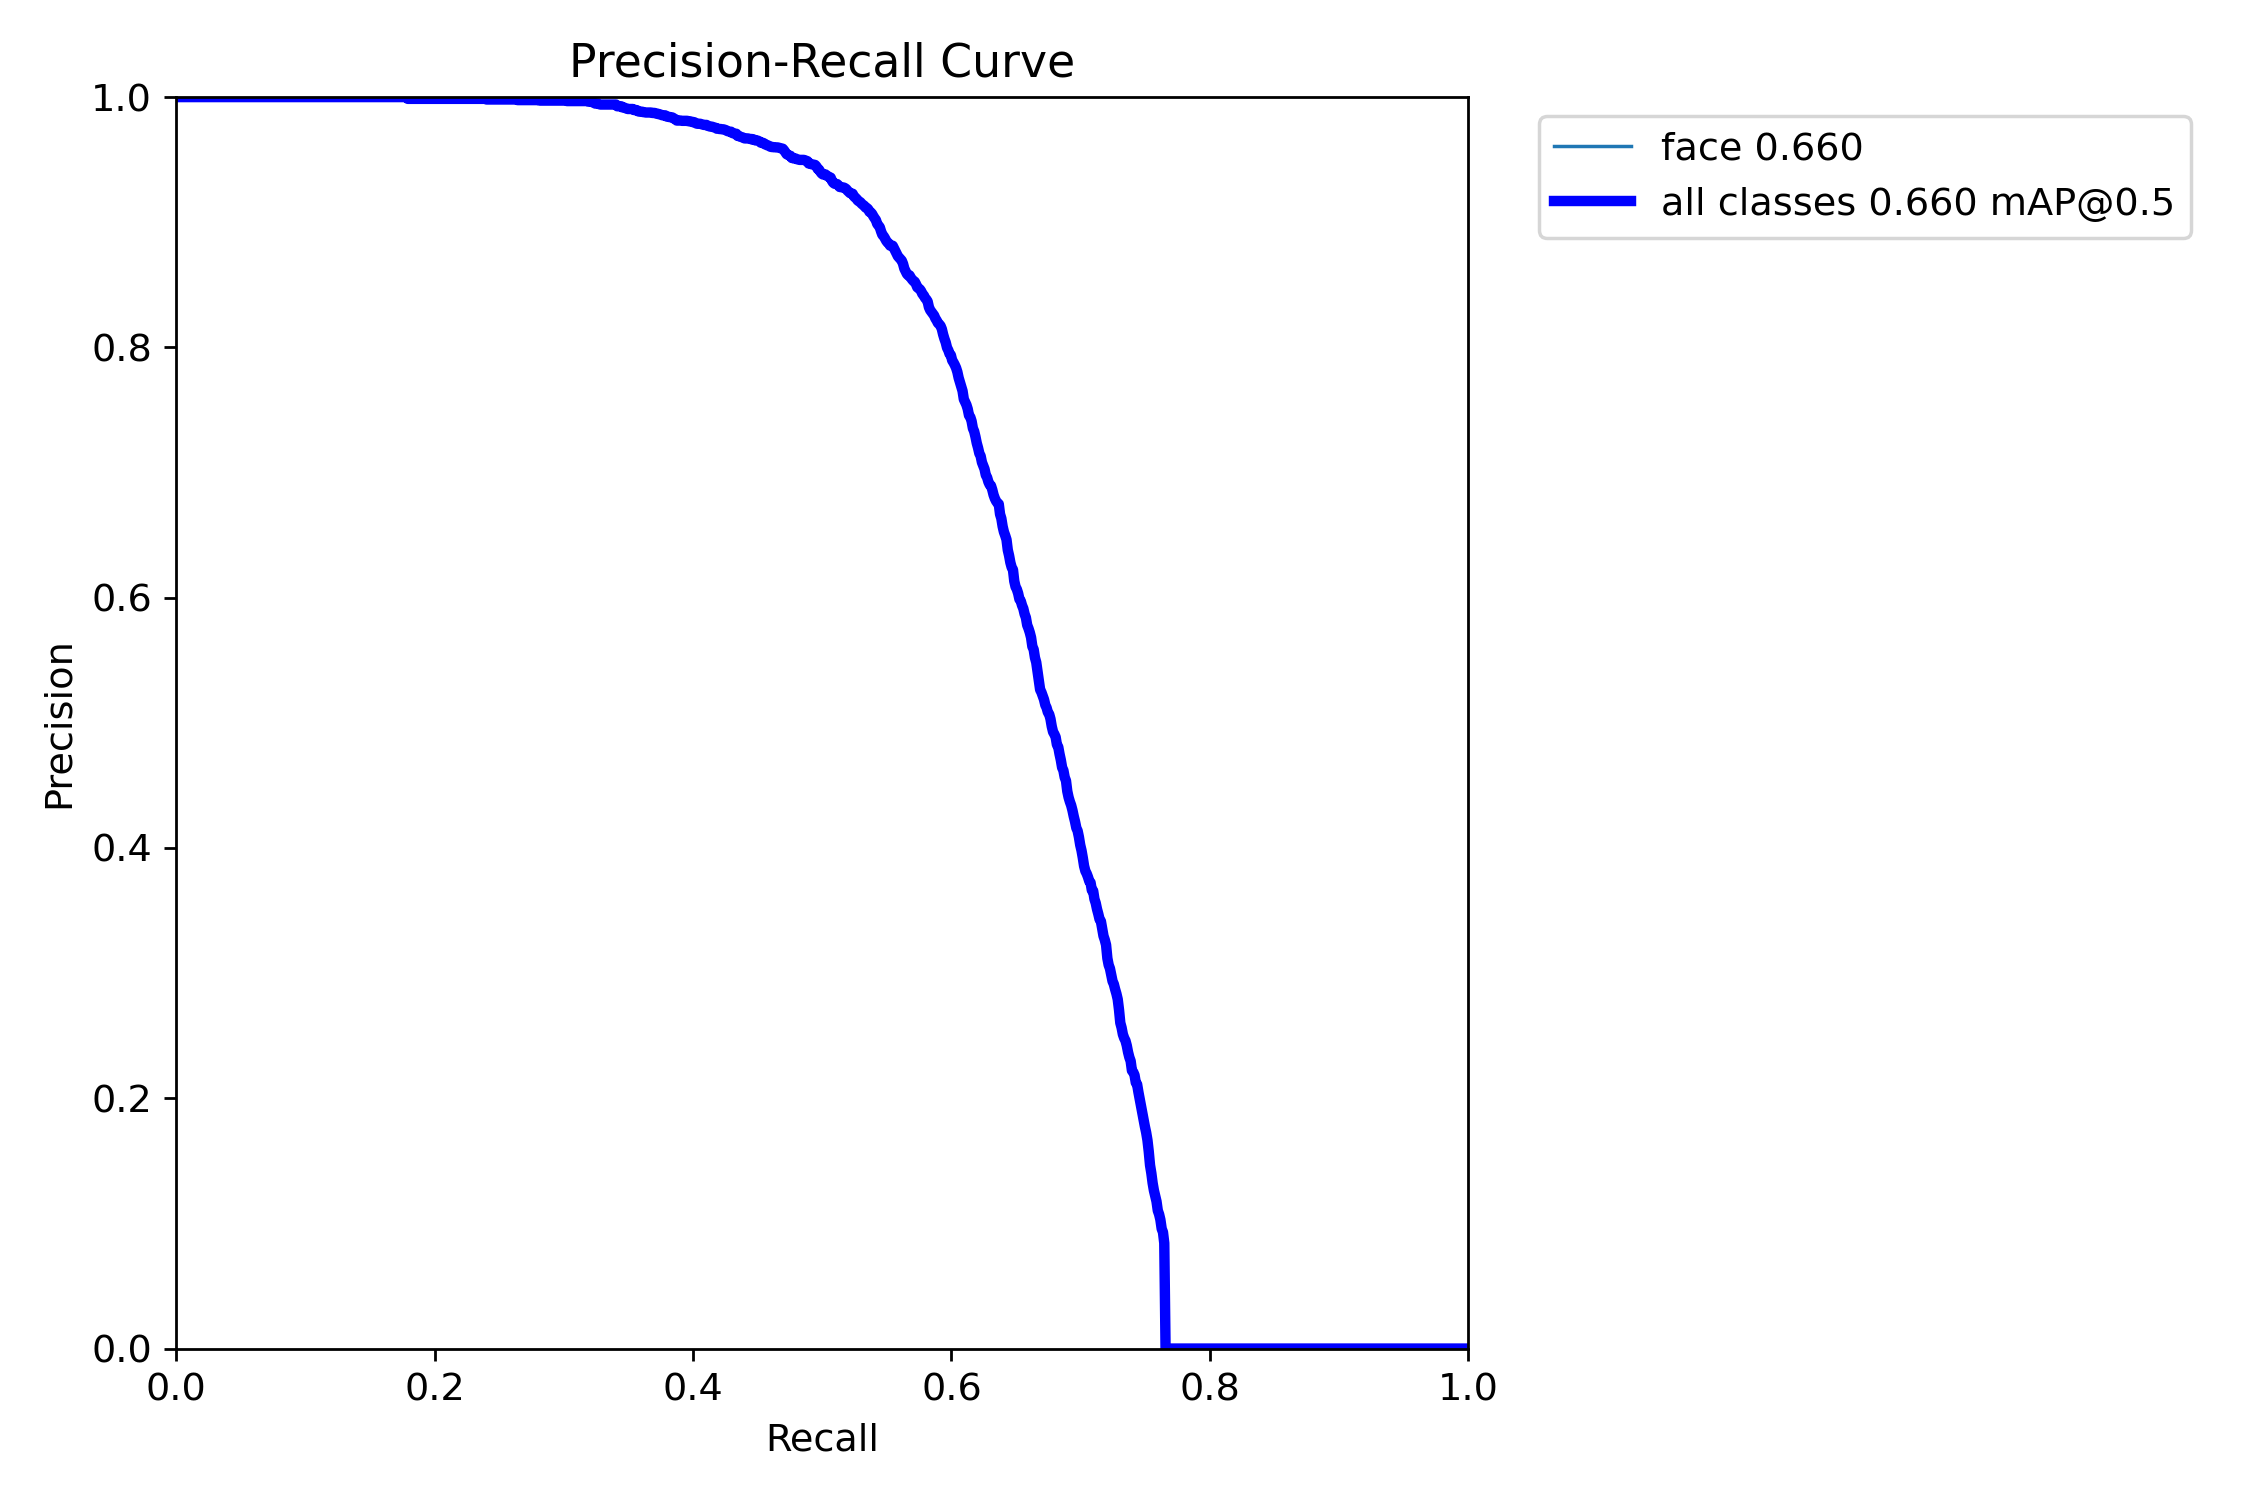

**BoxP_curve.png**

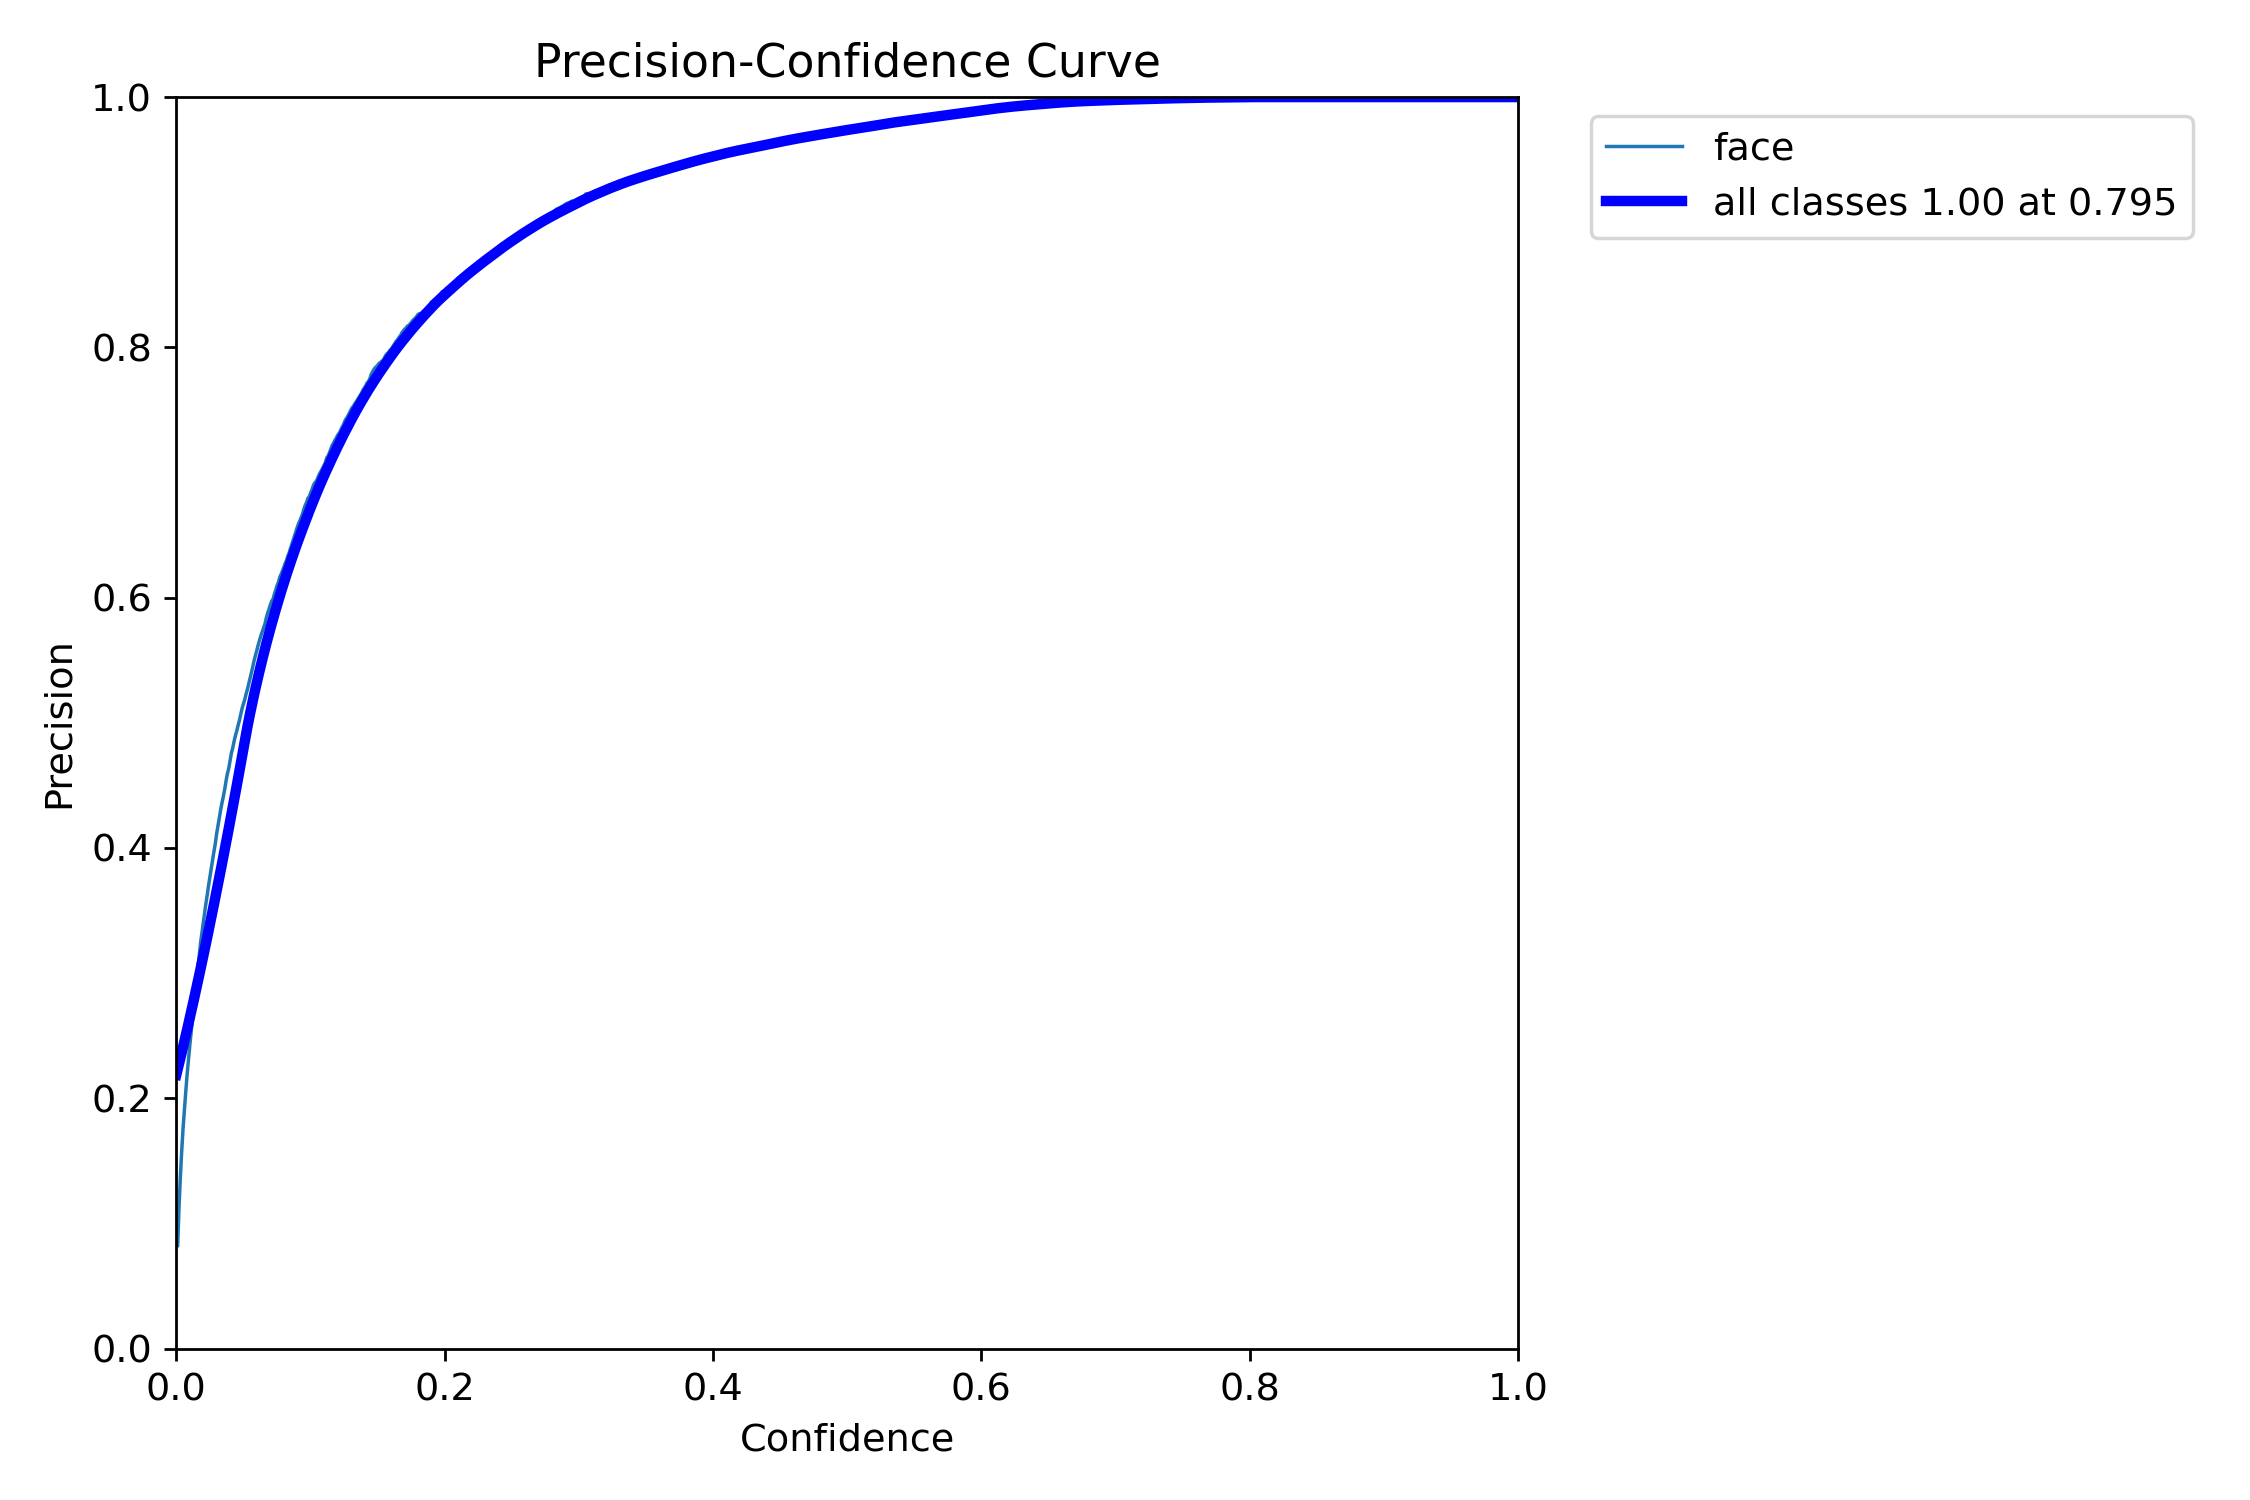

**BoxR_curve.png**

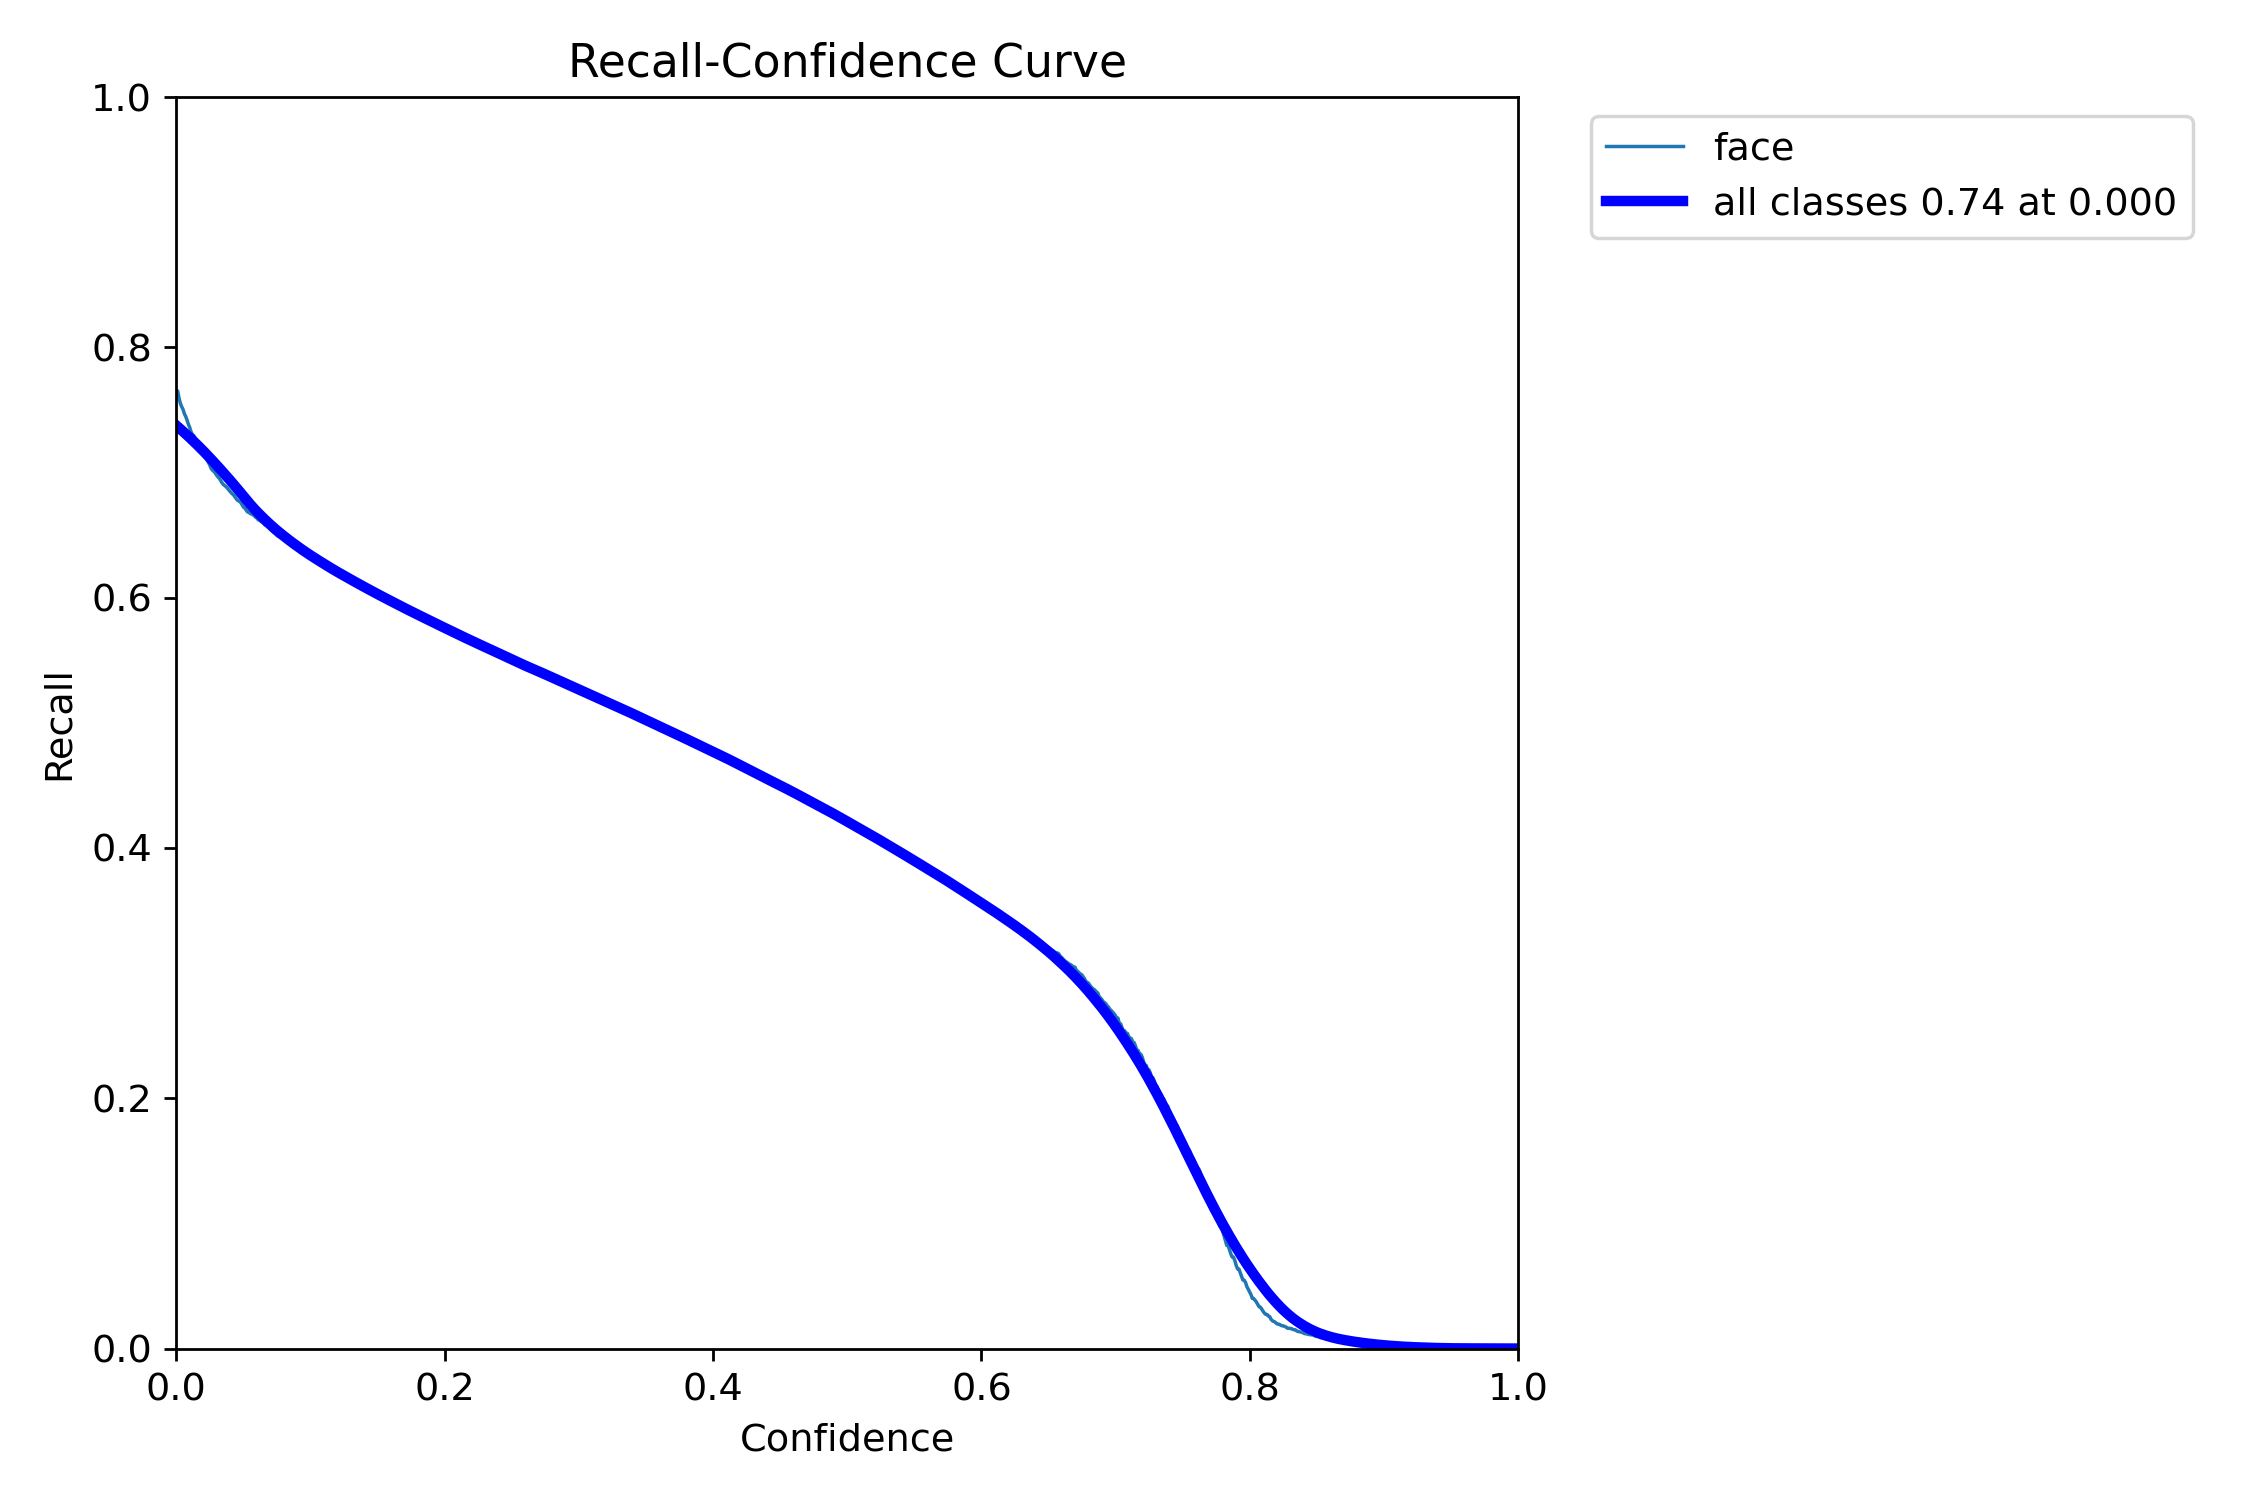

**val_batch0_labels.jpg**

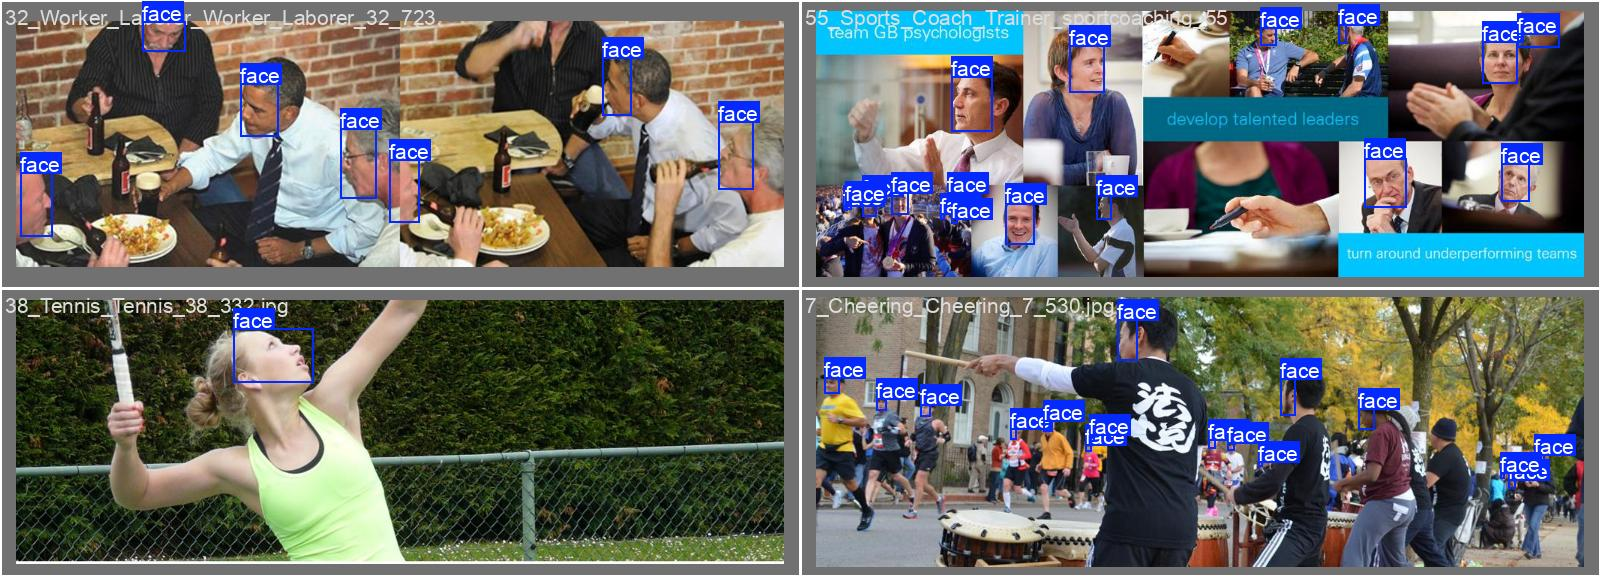

**val_batch0_pred.jpg**

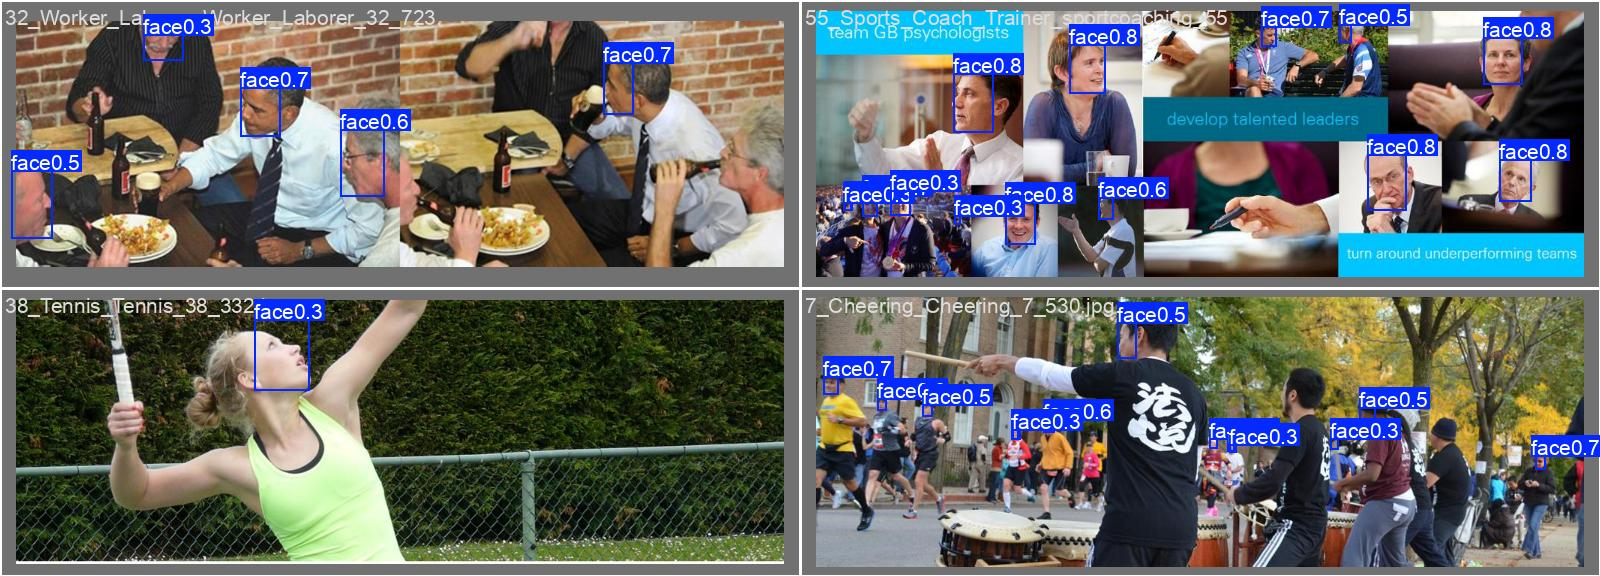

In [12]:
yolo_artifacts = [
    'results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png',
    'BoxF1_curve.png', 'BoxPR_curve.png', 'BoxP_curve.png', 'BoxR_curve.png',
    'val_batch0_labels.jpg', 'val_batch0_pred.jpg'
]
print('YOLO Run:', yolo_run)
for name in yolo_artifacts:
    path = yolo_run / name
    if path.exists():
        display(Markdown(f'**{name}**'))
        display(Image(filename=str(path)))
    else:
        print('Fehlt:', path)


## 12. Trainingsressourcen

Exakte Leistungsaufnahme in Watt wurde nicht gemessen. Dokumentiert werden GPU, Datenmenge, Epochen, Batch Size, Laufzeit, Modellgroesse und Trainingsverlauf.

In [13]:
def file_mb(path):
    path = Path(path)
    return path.stat().st_size / (1024 * 1024) if path.exists() else 0

yolo_final = [{k.strip(): v for k, v in r.items()} for r in read_csv(yolo_results)][-1]
resources = [
    ['YOLOv8m red6 ep10', 'AMD Radeon PRO W7800 48GB via ROCm/CUDA-API', 2147, 10, 2, f"{float(yolo_final['time'])/60:.1f} min", f"{file_mb(ROOT / 'trained_models/yolo_yolov8m_widerface_rocm_bs2_red6_ep10.pt'):.1f} MB", f"Precision {float(yolo_final['metrics/precision(B)']):.3f}, Recall {float(yolo_final['metrics/recall(B)']):.3f}, mAP50 {float(yolo_final['metrics/mAP50(B)']):.3f}"],
    ['FCOS red6 ep10', 'AMD Radeon PRO W7800 48GB via ROCm/CUDA-API', 2147, 10, 2, 'ca. 58 min beobachtet', f"{file_mb(ROOT / 'trained_models/fcos_resnet50_fpn_rocm_bs2_red6_ep10.pth'):.1f} MB", f"Mean Loss {float(f_hist[0]['mean_loss']):.3f} -> {float(f_hist[-1]['mean_loss']):.3f}"],
]
lines = ['| Modell | GPU | Trainingsbilder | Epochen | Batch | Trainingszeit | Modellgroesse | Hinweis |', '|---|---|---:|---:|---:|---:|---:|---|']
for r in resources:
    lines.append('|' + '|'.join(map(str, r)) + '|')
display(Markdown('\n'.join(lines)))


| Modell | GPU | Trainingsbilder | Epochen | Batch | Trainingszeit | Modellgroesse | Hinweis |
|---|---|---:|---:|---:|---:|---:|---|
|YOLOv8m red6 ep10|AMD Radeon PRO W7800 48GB via ROCm/CUDA-API|2147|10|2|16.1 min|49.6 MB|Precision 0.839, Recall 0.579, mAP50 0.660|
|FCOS red6 ep10|AMD Radeon PRO W7800 48GB via ROCm/CUDA-API|2147|10|2|ca. 58 min beobachtet|122.8 MB|Mean Loss 1.243 -> 0.735|

## 13. Kurzfazit

- **Breiter Vergleich:** FCOS gewinnt qualitativ mit dem hoechsten Recall. Faster R-CNN ist solide, aber langsamer und nicht besser als FCOS. RetinaNet ist schnell, aber verpasst zu viele Gesichter.
- **Warum YOLO trotzdem Favorit bleibt:** YOLO ist im Smoke-Vergleich nicht Recall-Sieger, aber fuer die Video-Pipeline am besten integrierbar und nach 10 Epochen schneller als FCOS.
- **Favoritenvergleich:** FCOS red6 ep10 erreicht 0,673 Recall, YOLOv8m red6 ep10 erreicht 0,488 Recall bei deutlich geringerer Latenz.
- **COCO-Baselines:** Ohne Face-Finetuning praktisch ungeeignet.